[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab0-ML/notebooks/01-Simple_examples.ipynb)

Version 27.11.2025, A. Lundervold / A. S. Lundervold

# A First Example of Machine Learning

Welcome to your first practical encounter with machine learning! 

In this Jupyter Notebook we will use machine learning to study some classic benchmark datasets. The goal is to give you a concrete understanding of what machine learning really is, and how it works in practice.

**What is Machine Learning?**

Traditionally we program computers by giving them explicit instructions: "do this, then this, then this". In machine learning we do something fundamentally different – we give the computer *data* and let it *learn* patterns from that data. The algorithm figures out how to solve the task based on the examples we give it.

**Why is This Important in Medicine?**

Imagine you want to create a program that can recognize cancer cells in microscope images. It would be extremely difficult to write explicit rules for what makes a cell a cancer cell. But with machine learning we can show the algorithm thousands of examples of normal and abnormal cells, and let it learn to distinguish between them.

---

> 💡 **Tip:** You will find notebook cells labeled "Your Turn!" below. These are meant for you to experiment with the code yourself.

> 🔧 **Advice:** Feel free to modify the code, change parameters, and explore on your own! Hands-on exploration leads to deeper understanding.

In [48]:
# ============================================================================
# ENVIRONMENT CHECK
# ============================================================================
# This cell checks if we are running in Google Colab or locally.
# This is important because some parts of the code need to be adapted for different environments.
# We do this check at the beginning of all notebooks in the course.

try:
    import google.colab
    colab = True
    print("✓ Running in Google Colab")
except:
    colab = False
    print("✗ NOT running in Google Colab")

✗ NOT running in Google Colab


## Our First Dataset: Iris Flowers

To get started we need data. We will start with a classic and well-studied dataset: **The Iris Flower Dataset** (https://archive.ics.uci.edu/ml/datasets/iris).

### Why the Iris Dataset?

1. **Simple and clear**: Bare 150 observations with 4 features each
2. **Well understood**: Used in machine learning since 1936!
3. **Clear demonstration**: Shows classification techniques in an understandable way
4. **Visually intuitive**: We can actually *see* the differences between the classes

Later in the course we will look at more complex (and more interesting!) datasets, including medical data.

<img src="https://raw.githubusercontent.com/HVL-ML/DAT158/main/notebooks/assets/iris.png" width="600">

**Figure 1: The three Iris species in the dataset.** *From left: Iris setosa, Iris versicolor and Iris virginica. Notice the visible differences in the flowers' shape and size – these are the features we will use to teach the computer to distinguish between them.*

### The Task: Classification

The goal is to **predict** which Iris species a flower belongs to, based on measurements of:
- **Sepal**: length and width
- **Petal**: length and width

The three species are:
- *Iris setosa*
- *Iris versicolor*  
- *Iris virginica*

> 📚 **Vocabulary:** Assigning each data point to a *class* is called **classification**. This is one of the most common tasks in machine learning.

> 🤔 **Reflection:** Why would we want a machine to classify flowers for us? Can you think of practical applications where classification is important? Think for example about medical diagnostics, spam filtering, or facial recognition.

---

# Set Up the Machine Learning Framework

Before we can begin with the actual machine learning, we need to import the necessary tools. In programming, a **library** is a collection of ready-made tools that help us with specific tasks without having to build everything from scratch.

### The most important libraries we use:

| Library | What it's used for |
|-----------|--------------------|
| **NumPy** | Numerical calculations, matrices and vectors |
| **Pandas** | Handling tabular data (like Excel, but more powerful!) |
| **Matplotlib** | Visualizations and plotting |
| **scikit-learn** | Machine learning algorithms |

Get familiar with these – you will use them a lot!

In [49]:
# ============================================================================
# IMPORT NECESSARY LIBRARIES
# ============================================================================

# NumPy: Fundamental library for numerical computations in Python
# We use the alias 'np' for shorter code
import numpy as np

# Pandas: Powerful tool for data manipulation and analysis
# Perfect for tabular data (think: Excel on steroids)
import pandas as pd

# Matplotlib: Standard library for visualization in Python
# The pyplot module gives us a MATLAB-like interface
import matplotlib.pyplot as plt

print("✓ All basic libraries imported!")

✓ All basic libraries imported!


In [50]:
# ============================================================================
# CONFIGURE THE WORKING ENVIRONMENT
# ============================================================================

# Set random seed for reproducibility
# This ensures that everyone running this notebook gets the same results
# The number 42 is arbitrary (but popular in data science!)
np.random.seed(42)

# Configure Matplotlib to display figures directly in the notebook
%matplotlib inline

print("✓ Environment is configured and ready!")

✓ Environment is configured and ready!


### scikit-learn: Our Machine Learning Library

`scikit-learn` is the most widely used Python library for machine learning. It offers:

- **Ready-made algorithms** for classification, regression, clustering, etc.
- **Simple interface**: All models follow the same pattern (fit → predict)
- **Good documentation**: https://scikit-learn.org

In [51]:
# Import the scikit-learn main library
import sklearn

# Show which version we are using (useful for reproducibility)
print(f"scikit-learn version: {sklearn.__version__}")

scikit-learn version: 1.6.1


---

# Load, Explore and Prepare the Data

In this section we will:

1. **Load** the dataset
2. **Explore** its features and labels
3. **Understand** the structure
4. **Convert** to Pandas DataFrame for easier manipulation

In [52]:
# Import the function to load the Iris dataset
from sklearn.datasets import load_iris

# Load the dataset
iris_dataset = load_iris()

print("✓ Iris dataset is loaded!")
print(f"  The dataset contains {iris_dataset['data'].shape[0]} observations")

✓ Iris dataset is loaded!
  The dataset contains 150 observations


In [53]:
# Show description of the dataset
print(iris_dataset['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [54]:
# Explore the features
features = iris_dataset['feature_names']
print("Features in the dataset:")
print("="*50)
for i, feature in enumerate(features, 1):
    print(f"  {i}. {feature}")

Features in the dataset:
  1. sepal length (cm)
  2. sepal width (cm)
  3. petal length (cm)
  4. petal width (cm)


In [55]:
# Explore the labels/targets
print("Classes (target labels) in the dataset:")
print("="*50)
for i, name in enumerate(iris_dataset['target_names']):
    print(f"  Class {i}: {name}")

Classes (target labels) in the dataset:
  Class 0: setosa
  Class 1: versicolor
  Class 2: virginica


In [56]:
# Create a Pandas DataFrame for easier handling
iris_df = pd.DataFrame(
    iris_dataset['data'],
    columns=features
)
iris_df['label'] = iris_dataset['target']

print("The first 10 observations:")
iris_df.head(10)

The first 10 observations:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


---

# Visualize the data

Data visualization is not just about making pretty figures – it helps us **understand** the relationships in the data.

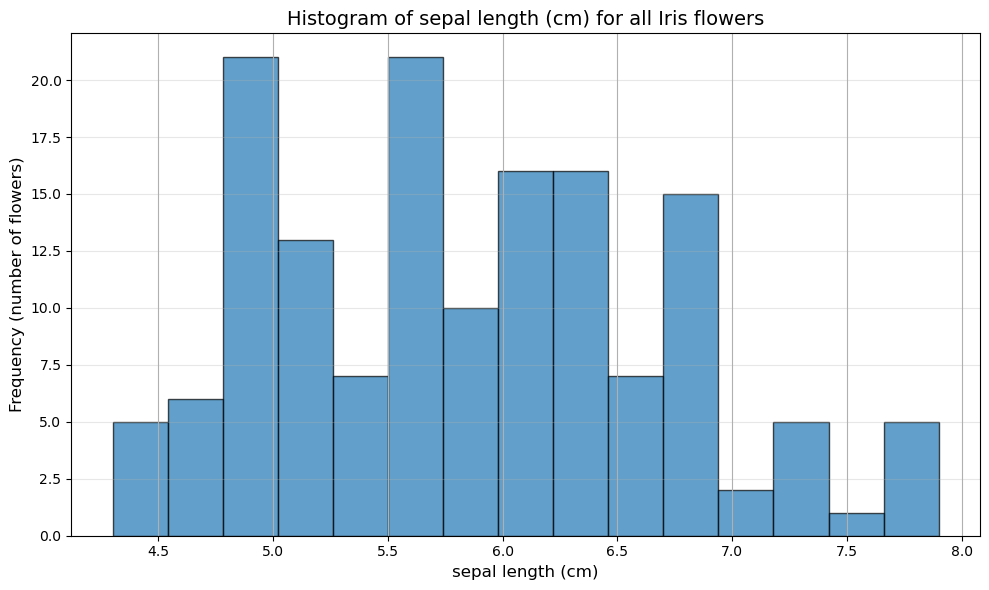


FIGURE 2: Histogram of sepal length
Interpretation: The histogram shows the distribution of sepal length
for all 150 Iris flowers. Most have a length between 5-7 cm.


In [57]:
# ============================================================================
# HISTOGRAM OF A SINGLE FEATURE
# ============================================================================

feat = 'sepal length (cm)'

fig, ax = plt.subplots(figsize=(10, 6))
iris_df[feat].hist(ax=ax, bins=15, edgecolor='black', alpha=0.7)
ax.set_xlabel(feat, fontsize=12)
ax.set_ylabel('Frequency (number of flowers)', fontsize=12)
ax.set_title(f'Histogram of {feat} for all Iris flowers', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFIGURE 2: Histogram of sepal length")
print("Interpretation: The histogram shows the distribution of sepal length")
print("for all 150 Iris flowers. Most have a length between 5-7 cm.")

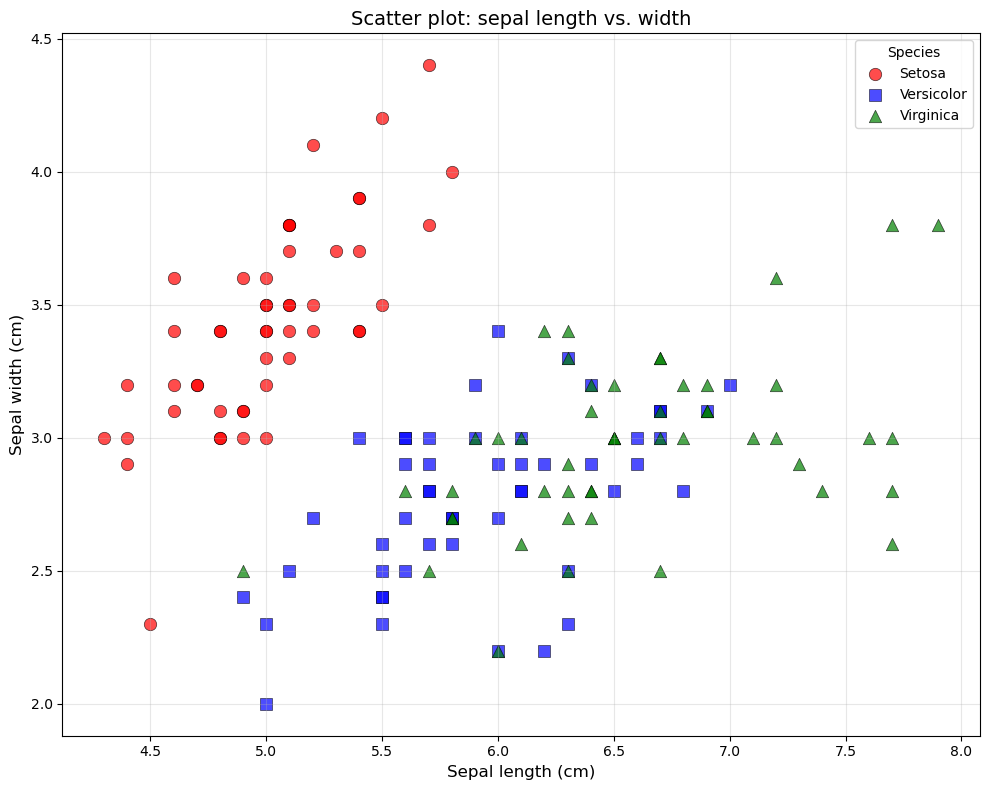


FIGURE 3: Scatter plot of sepal dimensions
Interpretation: Iris setosa (red) clearly stands out with shorter,
wider sepals. Versicolor and virginica overlap more.


In [58]:
# ============================================================================
# SCATTER PLOT: SEPAL LENGTH VS WIDTH
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['red', 'blue', 'green']
markers = ['o', 's', '^']
names = iris_dataset.target_names

for label in [0, 1, 2]:
    mask = iris_df['label'] == label
    ax.scatter(
        x=iris_df[mask]['sepal length (cm)'],
        y=iris_df[mask]['sepal width (cm)'],
        color=colors[label],
        label=names[label].capitalize(),
        s=80,
        marker=markers[label],
        alpha=0.7,
        edgecolors='black',
        linewidth=0.5
    )

ax.set_xlabel('Sepal length (cm)', fontsize=12)
ax.set_ylabel('Sepal width (cm)', fontsize=12)
ax.set_title('Scatter plot: sepal length vs. width', fontsize=14)
ax.legend(title='Species', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFIGURE 3: Scatter plot of sepal dimensions")
print("Interpretation: Iris setosa (red) clearly stands out with shorter,")
print("wider sepals. Versicolor and virginica overlap more.")

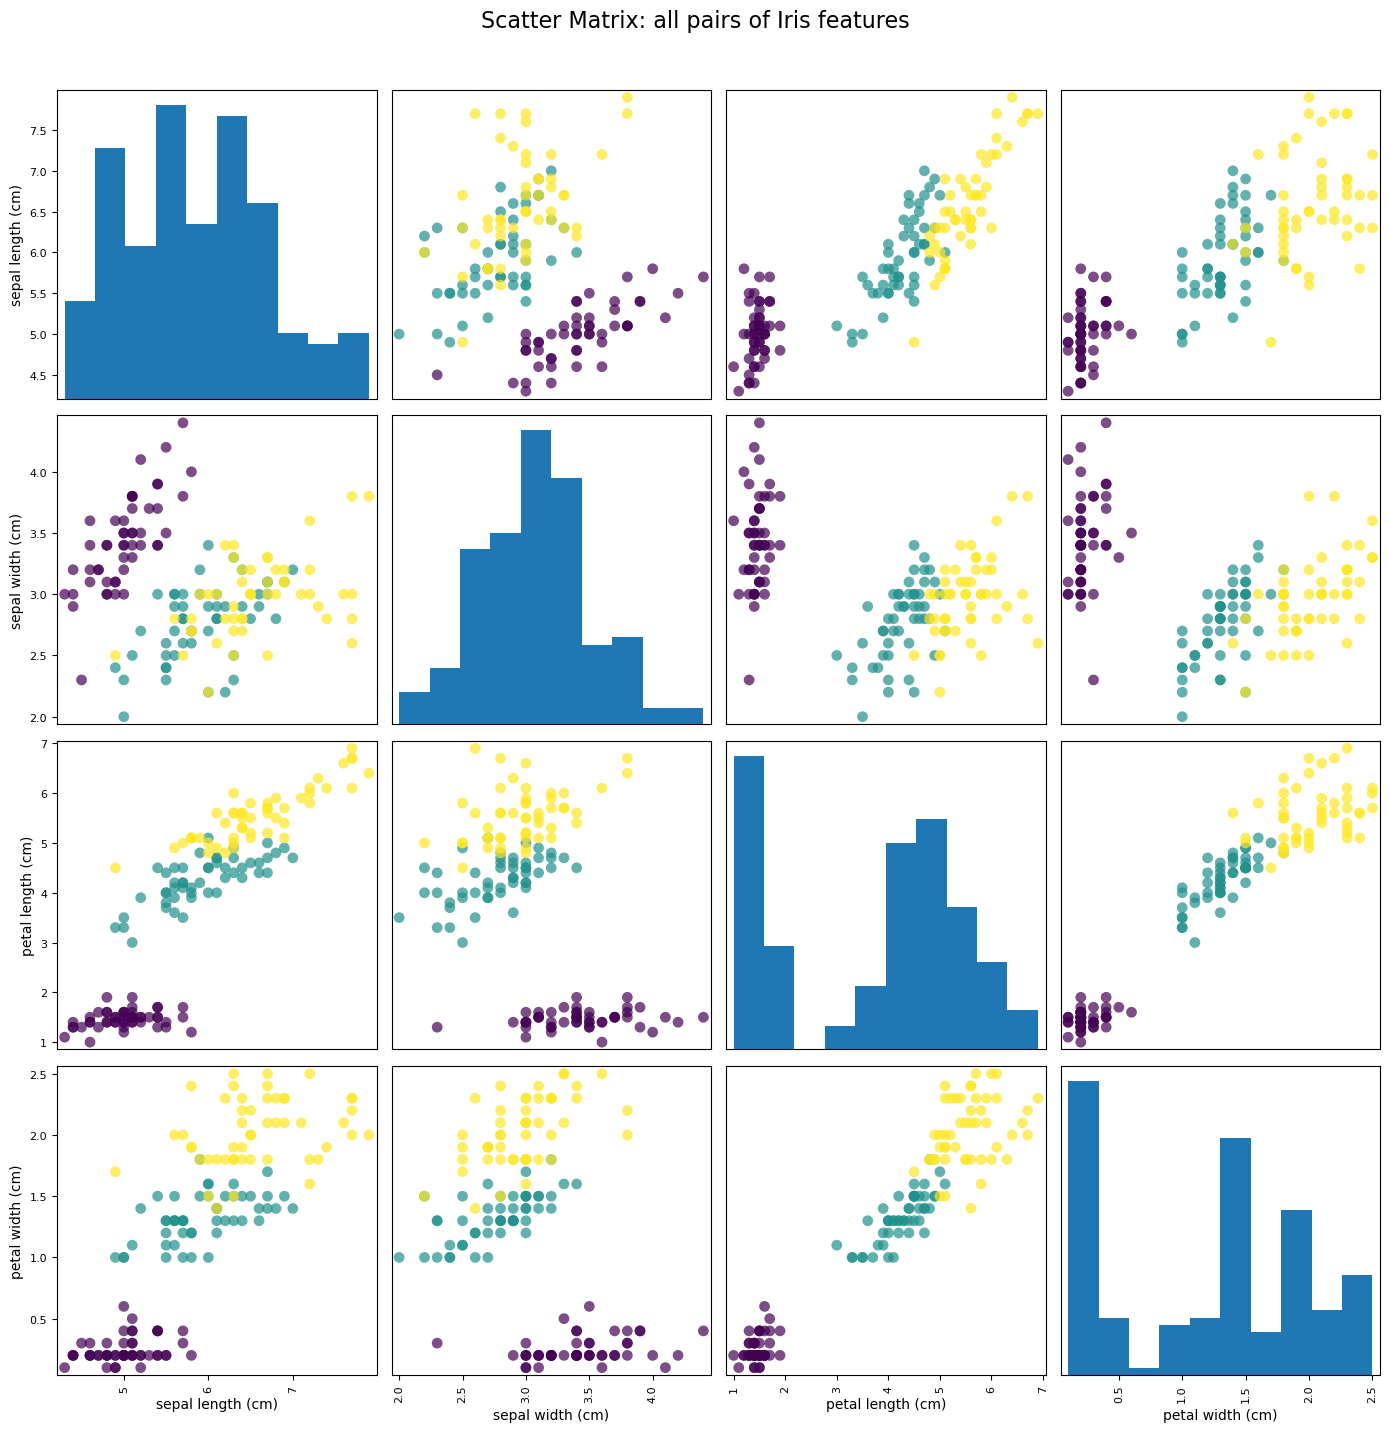


FIGURE 4: Scatter matrix
Interpretation: Petal measurements show the best separation between species.
This bodes well for machine learning!


In [59]:
# ============================================================================
# SCATTER MATRIX: ALL PAIRS
# ============================================================================

pd.plotting.scatter_matrix(
    iris_df[features],
    c=iris_df['label'],
    figsize=(14, 14),
    marker='o',
    s=60,
    alpha=0.7,
    diagonal='hist'
)
plt.suptitle('Scatter Matrix: all pairs of Iris features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("\nFIGURE 4: Scatter matrix")
print("Interpretation: Petal measurements show the best separation between species.")
print("This bodes well for machine learning!")

---

# Train a Machine Learning Model

Now we come to the core of machine learning: actually **building a model** that can learn from data and make predictions on new, unseen examples.

## From data to decisions

Imagine you are a doctor who needs to diagnose patients. Over the years you have seen thousands of patients and learned patterns: "Patients with these symptoms often have this disease." You use this experience to make diagnoses for new patients you have never met before.

A machine learning model does exactly the same:
1. **Learn from examples** (training): Look at data where we know the answer
2. **Generalize** (prediction): Use what it has learned on new data

But here comes a critical question: **How do we know that the model has actually learned something useful, and not just memorized the training data?**

---

## 🎯 Why Split the Data? The Most Important Insight in Machine Learning

This is perhaps the **most important concept** you will learn in this course:

> ⚠️ **The Golden Rule:** We must ALWAYS evaluate the model on data it has NOT seen during training!

### The problem: overfitting

Imagine a student who memorizes previous exam questions word for word, without understanding the concepts. On a test with exactly the same questions, the student scores 100%. But on a new exam with slightly different questions, the student fails completely.

This is called **overfitting** – the model "memorizes" the training data instead of learning the underlying patterns.

**Medical example:**
- A model trained to detect lung cancer on X-ray images
- If we evaluate on the same images used for training, the model may have "memorized" that "Image #47 = cancer"
- On new patients, the model may not work at all!

### The solution: train/test split

We split the data into two (or three) separate parts:

```
┌─────────────────────────────────────────────────────────────┐
│                    ALL DATA (100%)                          │
├────────────────────────────────────┬────────────────────────┤
│       TRAINING DATA (75%)          │     TEST DATA (25%)     │
│                                    │                        │
│   Used to BUILD the model          │  Used to EVALUATE      │
│   The model "sees" these data      │  The model has NEVER   │
│                                    │  seen these data       │
└────────────────────────────────────┴────────────────────────┘
```

### The three datasets (for more advanced use)

In practice, we often use **three** datasets:

| Dataset | Typical size | Purpose |
|----------|-----------------|--------|
| **Training data** | 60-80% | Learn the patterns – build the model |
| **Validation data** | 10-20% | Tune model hyperparameters |
| **Test data** | 10-20% | Final, unbiased evaluation |

**Why validation?**
- When we try different models or settings, we choose the one that works best on the validation data
- The test data is held back completely until the end – it is our "exam"
- If we use test data to choose a model, we have "cheated" and don't know how good the model really is

### Medical perspective: why this is critical

In medicine, the consequences of overfitting can be serious:

| Scenario | Consequence of overfitting |
|----------|----------------------------|
| Cancer diagnosis | False positives → unnecessary biopsies and anxiety |
| Sepsis prediction | False negatives → delayed treatment, death |
| Drug dosing | Wrong dose → toxicity or lack of effect |

> 💡 **Important insight:** A model that looks fantastic on training data, but fails on new data, is *worthless* in clinical practice. This is why train/test split is not optional – it is **fundamental**!

---

## Let's Build Our First Model!

Now we will:
1. Choose which features we want to use
2. Split the data into training and test
3. Train a classification model
4. Evaluate how well the model works on test data

In [60]:
# ============================================================================
# CHOOSE FEATURES AND LABELS
# ============================================================================

# For demonstration we only use sepal measurements (2 of 4 features)
X = iris_dataset['data'][:, [0, 1]]
y = iris_dataset['target']

print(f"X (features): {X.shape} - {X.shape[0]} flowers with {X.shape[1]} measurements")
print(f"y (labels): {y.shape} - {y.shape[0]} class labels")

X (features): (150, 2) - 150 flowers with 2 measurements
y (labels): (150,) - 150 class labels


In [61]:
# ============================================================================
# SPLIT DATA INTO TRAINING AND TEST
# ============================================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42
)

print(f"Training data: {X_train.shape[0]} observations (75%)")
print(f"Test data:     {X_test.shape[0]} observations (25%)")

Training data: 112 observations (75%)
Test data:     38 observations (25%)


## 🌲 Random Forest: Our First Machine Learning Model

Now we will choose which algorithm to use. There are hundreds of machine learning algorithms, but we will start with one of the most popular and reliable: **Random Forest**.

### What is a Random Forest?

The name "Random Forest" actually gives a good picture of how the algorithm works:
- It consists of many **decision trees**
- Each tree is slightly different because it is built with **randomness**
- Together the trees form a "forest" that makes decisions by **majority voting**

### The Building Block: Decision Trees

A **decision tree** is like a flowchart with yes/no questions:

```
                    Is petal length < 2.5 cm?
                           /          \
                         YES           NO
                         |              |
                    SETOSA      Is petal width < 1.7 cm?
                                      /          \
                                    YES           NO
                                    |              |
                              VERSICOLOR      VIRGINICA
```

**Medical analogy:** Think of it as a diagnostic algorithm:
- "Does the patient have a fever?" → Yes/No
- "Is the CRP value elevated?" → Yes/No
- "Is there a cough?" → Yes/No
- → Conclusion: probable diagnosis

### From One Tree to an Entire Forest

A single decision tree can be **unstable** – small changes in the data can result in a completely different tree. The solution is to use *many* trees:

```
┌─────────────────────────────────────────────────────────────────┐
│                      RANDOM FOREST                              │
│                                                                 │
│   🌲 Tre 1    🌲 Tre 2    🌲 Tre 3    ...    🌲 Tre 100        │
│      |           |           |                  |               │
│   Setosa    Versicolor    Setosa           Setosa               │
│                                                                 │
│   ─────────────────────────────────────────────────────────     │
│                    MAJORITY VOTING                              │
│                           ↓                                     │
│                  Final prediction: SETOSA                       │
└─────────────────────────────────────────────────────────────────┘
```

### What Makes Random Forest "Random"?

Two types of randomness make each tree unique:

1. **Bootstrap sampling**: Each tree is trained on a random sample of the training data (with replacement)
2. **Random feature selection**: At each split in the tree, only a random subset of features is considered

This randomness makes the model more **robust** and less prone to overfitting.

---

## 🎓 What Happens When We "Train" the Model?

When we call `rf.fit(X_train, y_train)`, the following happens:

### Step 1: Build Many Decision Trees
For each of the 100 trees (we use `n_estimators=100`):

1. **Draw a random sample** of the training data
2. **Build a tree** by finding the best questions that separate the classes
3. **Repeat** until the tree is fully built

### Step 2: Find the Best Splits
For each question in the tree, the algorithm:
- Tries different threshold values (e.g., "Is length < 5.0?" vs "Is length < 5.5?")
- Chooses the question that **best separates the classes** from each other
- Measures this with a metric called **Gini impurity** or **information gain**

### What Does the Model Actually "Learn"?

The model learns a collection of **decision rules**:

| Tree | Learned rules |
|-----|-------------|
| Tree 1 | "If sepal_length < 5.45 AND sepal_width > 2.8 → Setosa" |
| Tree 2 | "If sepal_length < 5.55 AND sepal_width > 2.75 → Setosa" |
| ... | ... |
| Tree 100 | "If sepal_length < 5.35 AND sepal_width > 2.9 → Setosa" |

**Important insight:** The model does *not* learn a mathematical formula, but a *collection of rules* that describe how the features relate to the classes.

---

## 💾 How is the Knowledge Stored in the Model?

After training, the `rf` object contains:

1. **100 decision trees** – each with its own structure
2. **Split rules** – which features and threshold values are used
3. **Leaf-node predictions** – which class is predicted at each terminal node

```python
# After training we can inspect the model:
rf.n_estimators         # Number of trees (100)
rf.feature_importances_ # How important each feature is
rf.estimators_[0]       # The first tree
```

### When we make predictions (`rf.predict(X_test)`):

1. **Each tree** gets to see the new data
2. **Each tree votes** for the class it thinks the data belong to
3. **The majority wins** – the class that most trees voted for becomes the prediction

---

## Why is Random Forest so popular?

| Advantage | Explanation |
|----------|------------|
| **Robust** | Many trees compensate for each other’s errors |
| **Little tuning** | Often works well "out of the box" |
| **Handles complexity** | Can learn non-linear relationships |
| **Interpretable** | Can tell us which features matter most |
| **Fast** | Trees can be built in parallel |

> 💡 **In medicine:** Random Forest is used, for example, to:
> - Predict patient outcomes based on clinical variables
> - Classify medical images
> - Identify risk factors for disease

---

Now we are ready to build our Random Forest model!


In [62]:
# ============================================================================
# CREATE AND TRAIN THE MODEL
# ============================================================================

from sklearn.ensemble import RandomForestClassifier

# Create a model with 100 decision trees
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf.fit(X_train, y_train)

print("✓ Model is trained!")

✓ Model is trained!


## 📊 Model evaluation: how do we know if it’s good enough?

Now we come to one of the most important steps in machine learning: **evaluation**. A model is worthless if we don’t know how well it works — and in medicine, incorrect predictions can have serious consequences.

### Why is evaluation so important in medicine?

Imagine the following scenario:

> *"We have developed an AI model that can detect cancer with 95% accuracy!"*

That sounds impressive, but **is it good enough?** The answer depends on:
- What do the 5% errors mean?
- Who gets misclassified?
- What are the consequences of the errors?

---

## 🎯 Evaluation metrics: more than just "accuracy"

### 1. Accuracy

The simplest metric — the proportion of correct predictions:

$$\text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}}$$

**Problem:** Accuracy can be misleading!

**Example:** A model for detecting a rare disease (1% prevalence):
- The model always says "healthy" → 99% accuracy!
- But it catches **none** of the sick patients

### 2. Confusion matrix

To understand *what kinds* of mistakes the model makes, we use a confusion matrix:

```
                        PREDICTED
                    Positive    Negative
                  ┌──────────┬──────────┐
ACTUAL   Positive │    TP    │    FN    │
                  │ (True    │ (False   │
                  │ positive)│ negative)│
                  ├──────────┼──────────┤
         Negative │    FP    │    TN    │
                  │ (False   │ (True    │
                  │ positive)│ negative)│
                  └──────────┴──────────┘
```

| Term | Meaning | Clinical consequence |
|------|---------|----------------------|
| **TP** (True Positive) | Sick, correctly identified | ✓ The patient receives treatment |
| **TN** (True Negative) | Healthy, correctly identified | ✓ The patient avoids unnecessary treatment |
| **FP** (False Positive) | Healthy, but classified as sick | ⚠️ Unnecessary anxiety, treatment, and costs |
| **FN** (False Negative) | Sick, but classified as healthy | ❌ **DANGEROUS!** The patient does not receive treatment |

### 3. Sensitivity and specificity

These two metrics are **essential** in medicine:

**Sensitivity (Recall / True Positive Rate):**
$$\text{Sensitivity} = \frac{TP}{TP + FN} = \frac{\text{Correctly identified sick}}{\text{All who are actually sick}}$$

> *"How many of the sick do we catch?"*

**Specificity (True Negative Rate):**
$$\text{Specificity} = \frac{TN}{TN + FP} = \frac{\text{Correctly identified healthy}}{\text{All who are actually healthy}}$$

> *"How many healthy people do we avoid misdiagnosing?"*

### 4. Precision

$$\text{Precision} = \frac{TP}{TP + FP} = \frac{\text{Correctly identified sick}}{\text{All the model says are sick}}$$

> *"When the model says 'sick', how often is it right?"*

### 5. F1-score

Combines precision and recall into a single metric:

$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

---

## ⚖️ Which metric should you use?

**It depends on the context!** Here are some guidelines:

| Situation | Prioritize | Reason |
|-----------|------------|--------|
| **Screening for serious disease** | High sensitivity | Better to have some false alarms than to miss sick patients |
| **Confirmatory test before invasive treatment** | High specificity | Avoid unnecessary surgery/chemotherapy |
| **Balanced problem** | F1-score | Compromise between precision and recall |
| **Imbalanced classes** | Avoid accuracy! | Use F1, AUC-ROC, or balanced accuracy |

### Medical example: COVID-19 rapid test

- **High sensitivity matters most**: we want to catch all infected people
- We accept some false positives (they can take a PCR test afterwards)
- A false negative = an infected person spreads the virus unchecked

### Medical example: biopsy before cancer treatment

- **High specificity matters most**: avoid unnecessary biopsies
- A biopsy has risk (infection, bleeding, pain)
- Better to observe a bit longer than to operate on healthy patients

---

## 🏥 From evaluation to action: "actionable information"

An evaluation is only useful if it leads to **better decisions**. Ask yourself:

### 1. What is the clinical context?
- Screening vs diagnosis vs prognosis?
- What are the alternatives if the model is not used?
- What are the consequences of incorrect decisions?

### 2. What are the decision thresholds?

Most models output a **probability**, not just yes/no:

```
Patient A: 73% probability of diabetes
Patient B: 51% probability of diabetes
Patient C: 12% probability of diabetes
```

Where do we set the cutoff? At 50%? 30%? 70%?

| Low threshold (e.g. 30%) | High threshold (e.g. 70%) |
|--------------------------|--------------------------|
| High sensitivity | Low sensitivity |
| Low specificity | High specificity |
| Catch more sick patients | Fewer false alarms |
| More unnecessary tests | Risk missing sick patients |

### 3. Communicate uncertainty!

A good medical AI does not only say "diabetes" or "no diabetes", but:

> *"Based on the model, this patient has a 73% probability of diabetes.
> Recommended action: perform an HbA1c test for confirmation."*

### 4. Integrate with the clinical workflow

```
┌─────────────────────────────────────────────────────────────┐
│                 CLINICAL DECISION SUPPORT                   │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│  Model prediction: High risk of diabetes (73%)              │
│                                                             │
│  Recommended actions:                                       │
│  ☐ Order HbA1c test                                         │
│  ☐ Schedule follow-up appointment                           │
│  ☐ Provide lifestyle advice                                 │
│                                                             │
│  Model limitations:                                         │
│  • Trained on data from 2015–2020                           │
│  • Sensitivity: 82%, Specificity: 76%                       │
│  • Not validated for patients under 18 years                │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

---

## 📈 Summary: evaluation checklist

Before you trust a machine-learning model in medicine, check:

| ✓ | Question |
|---|----------|
| ☐ | Is the model evaluated on **independent test data**? |
| ☐ | Are the evaluation metrics **relevant to the context**? |
| ☐ | Are **sensitivity and specificity** reported? |
| ☐ | Do we know performance on **subgroups**? (sex, age, ethnicity) |
| ☐ | Is it clear **which actions** should follow from the predictions? |
| ☐ | Is **uncertainty** communicated? |

> 💡 **Remember:** A model with 78% accuracy can be excellent in one context and useless in another. Context is everything!

---

Now, let’s evaluate our Iris model:


In [63]:
# ============================================================================
# EVALUATE THE MODEL
# ============================================================================

from sklearn.metrics import accuracy_score

# Make predictions on the test data
y_pred = rf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel accuracy: {accuracy:.1%}")
print(f"→ {int(accuracy * len(y_test))} out of {len(y_test)} flowers classified correctly")


Model accuracy: 78.9%
→ 30 out of 38 flowers classified correctly


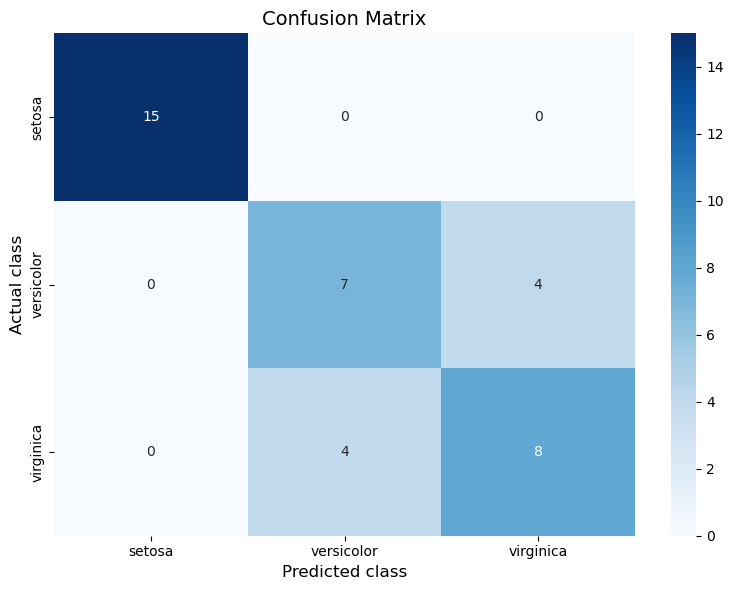


FIGURE: Confusion Matrix

Interpretation:
- The diagonal (top-left to bottom-right) shows CORRECT predictions
- All other cells show INCORRECT predictions
- Large values on the diagonal = a better model
- Example: If cell (setosa, versicolor) = 2, it means 2 setosa flowers
  were incorrectly classified as versicolor


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.64      0.64      0.64        11
   virginica       0.67      0.67      0.67        12

    accuracy                           0.79        38
   macro avg       0.77      0.77      0.77        38
weighted avg       0.79      0.79      0.79        38


Metric definitions:
─────────────────────────────────────────────────────────────
• Precision: Of all predictions of class X, how many were correct?
  → High precision = few false positives

• Recall (Sensitivity): Of all true examples of class X, how many did we find?
  → H

In [64]:
# ============================================================================
# COMPREHENSIVE MODEL EVALUATION
# ============================================================================
# Let's use multiple evaluation metrics to get a more complete picture

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)
import seaborn as sns

# -----------------------------------------------------------------------------
# 1. CONFUSION MATRIX
# -----------------------------------------------------------------------------
# Shows how many of each class were correctly/incorrectly classified

cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,           # Show numbers in cells
    fmt='d',              # Integer format
    cmap='Blues',         # Color scale
    xticklabels=iris_dataset.target_names,  # Class names on x-axis
    yticklabels=iris_dataset.target_names,  # Class names on y-axis
    ax=ax,
)
ax.set_xlabel('Predicted class', fontsize=12)
ax.set_ylabel('Actual class', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("FIGURE: Confusion Matrix")
print("=" * 60)
print(
    """
Interpretation:
- The diagonal (top-left to bottom-right) shows CORRECT predictions
- All other cells show INCORRECT predictions
- Large values on the diagonal = a better model
- Example: If cell (setosa, versicolor) = 2, it means 2 setosa flowers
  were incorrectly classified as versicolor
"""
)

# -----------------------------------------------------------------------------
# 2. CLASSIFICATION REPORT
# -----------------------------------------------------------------------------
# Gives precision, recall and F1-score for each class

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris_dataset.target_names,
    )
)

print(
    """
Metric definitions:
─────────────────────────────────────────────────────────────
• Precision: Of all predictions of class X, how many were correct?
  → High precision = few false positives

• Recall (Sensitivity): Of all true examples of class X, how many did we find?
  → High recall = few false negatives

• F1-score: Harmonic mean of precision and recall
  → Balanced measure when both are important

• Support: Number of true examples of each class in the test set
─────────────────────────────────────────────────────────────
"""
)

# -----------------------------------------------------------------------------
# 3. DETAILED METRICS
# -----------------------------------------------------------------------------

print("=" * 60)
print("DETAILED METRICS")
print("=" * 60)

# For multiclass we use 'weighted' to account for class sizes
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(
    f"""
Weighted averages (accounting for class sizes):
──────────────────────────────────────────────────────
  Accuracy:   {accuracy:.1%}  (proportion correct overall)
  Precision:  {precision:.1%}  (how precise is the model?)
  Recall:     {recall:.1%}  (how many do we catch?)
  F1-score:   {f1:.1%}  (balanced measure)
"""
)

# -----------------------------------------------------------------------------
# 4. ANALYSIS OF MISCLASSIFICATIONS
# -----------------------------------------------------------------------------

print("=" * 60)
print("ANALYSIS OF MISCLASSIFICATIONS")
print("=" * 60)

# Find which examples were misclassified
error_indices = y_test != y_pred
antall_feil = sum(error_indices)

print(f"\nNumber of misclassifications: {antall_feil} out of {len(y_test)}")

if antall_feil > 0:
    print("\nDetails about the errors:")
    print("-" * 40)
    for i, (faktisk, predikert) in enumerate(
        zip(y_test[error_indices], y_pred[error_indices])
    ):
        faktisk_navn = iris_dataset.target_names[faktisk]
        predikert_navn = iris_dataset.target_names[predikert]
        print(
            f"  Error {i+1}: Actual = {faktisk_navn}, Predicted = {predikert_navn}"
        )

print(
    """

💡 Insight:
──────────────────────────────────────────────────────
Notice which classes are confused. In the Iris dataset, versicolor and
virginica are typically the hardest to separate because they overlap
more in feature space (see the scatter matrix from earlier).

In a medical context we would analyze:
- Are the errors systematic? (Do we always miss the same type of patient?)
- What are the consequences of the different error types?
- Can we collect more data for the problematic cases?
"""
)


---

# 🔍 Explainable AI (XAI) and Trustworthy AI

We have now trained a model and evaluated its performance. But in medicine it is not enough that the model works — we must also **understand why** it makes the decisions it makes, and we must be able to **trust** it.

## What is Explainable AI (XAI)?

**Explainable AI (XAI)** is about making machine-learning models *understandable* to humans. Instead of a "black box" that only gives an answer, we want insight into:

- **Which features** influence the predictions the most?
- **Why** was this specific patient classified this way?
- **When** can we trust the model’s predictions?

### Why is XAI important in medicine?

| Situation | Without XAI | With XAI |
|-----------|-------------|----------|
| Doctor receives an AI recommendation | "The patient has a 73% risk of diabetes" | "73% risk based on: high glucose (contributes 45%), high BMI (contributes 30%), family history (contributes 15%)" |
| Patient asks "why?" | "That’s what the model says" | "Because your lab values and weight history match patterns we see in people with diabetes" |
| A misdiagnosis is discovered | Impossible to understand what went wrong | Can identify which factors misled the model |

> 📜 **Regulatory requirement:** The EU AI Act requires that high-risk AI systems (including medical AI) must be explainable and transparent.

---

## 🔐 Trustworthy AI: more than explainability

**Trustworthy AI** is a broader concept that includes multiple dimensions:

```
┌─────────────────────────────────────────────────────────────────┐
│                    TRUSTWORTHY AI                               │
│                                                                 │
│  ┌─────────────┐  ┌─────────────┐  ┌─────────────┐              │
│  │  ACCURACY   │  │ EXPLAINA-   │  │  FAIRNESS   │              │
│  │  Accuracy   │  │ BILITY      │  │  Fairness   │              │
│  │             │  │ Explain-    │  │             │              │
│  │  "Does it   │  │ ability     │  │  "Does it   │              │
│  │   work?"    │  │             │  │   work      │              │
│  │             │  │  "Why?"     │  │   equally   │              │
│  │             │  │             │  │   for all?" │              │
│  └─────────────┘  └─────────────┘  └─────────────┘              │
│                                                                 │
│  ┌─────────────┐  ┌─────────────┐  ┌─────────────┐              │
│  │ ROBUSTNESS  │  │  PRIVACY    │  │ ACCOUNTA-   │              │
│  │ Robustness  │  │  Privacy    │  │ BILITY      │              │
│  │             │  │             │  │ Account-    │              │
│  │  "Does it   │  │ "Is data    │  │ ability     │              │
│  │   tolerate  │  │  protected?"│  │  "Who is    │              │
│  │   noise?"   │  │             │  │   respon-   │              │
│  │             │  │             │  │   sible?"   │              │
│  └─────────────┘  └─────────────┘  └─────────────┘              │
└─────────────────────────────────────────────────────────────────┘
```

### The six pillars of Trustworthy AI

| Pillar | Description | Medical relevance |
|--------|-------------|------------------|
| **1. Accuracy** | The model makes correct predictions | Wrong diagnosis = wrong treatment |
| **2. Explainability** | We understand why the model predicts | The doctor must be able to explain it to the patient |
| **3. Fairness** | The model works similarly for all groups | Must not discriminate by sex, ethnicity, age |
| **4. Robustness** | The model tolerates variation and noise | Must work on data from different hospitals/equipment |
| **5. Privacy** | Patient data are protected | GDPR and health-data regulations |
| **6. Accountability** | It’s clear who is responsible when errors happen | Who is responsible if AI gives bad advice? |

---

## 🔬 XAI techniques in practice

There are multiple methods for explaining machine-learning models:

### 1. Feature importance (global explanation)
**Question:** "In general, which features are most important for the model?"

→ We have already seen this! Random Forest gives us `feature_importances_`.

### 2. Permutation importance (global explanation)
**Question:** "How much does performance drop if we randomly shuffle one feature?"

→ A more reliable measure than built-in feature importance.

### 3. SHAP values (local + global explanation)
**Question:** "For this *specific* prediction, how did each feature contribute?"

→ Provides both individual explanations and an overall view.

### 4. LIME (Local Interpretable Model-agnostic Explanations)
**Question:** "Can we fit a simple model that explains this one prediction?"

→ Trains an interpretable model locally around the prediction.

### 5. Partial dependence plots (global explanation)
**Question:** "How does the prediction change when we vary one feature?"

→ Shows the relationship between a feature and the prediction.

---

## Let’s demonstrate XAI on the Iris model!


               EXPLAINABLE AI (XAI) FOR THE IRIS MODEL

──────────────────────────────────────────────────────────────────────
1. FEATURE IMPORTANCE - Which features matter most?
──────────────────────────────────────────────────────────────────────


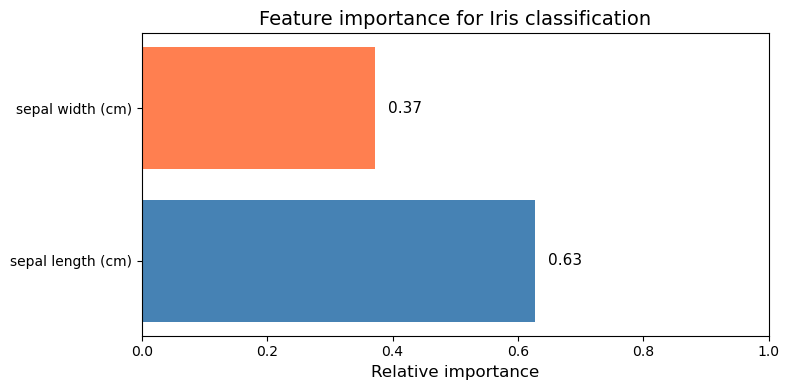


Interpretation:
  • Sepal length contributes 62.7% to the model's decisions
  • Sepal width contributes  37.3% to the model's decisions

  → This tells us that sepal length
    is the most important feature for separating the Iris species.


──────────────────────────────────────────────────────────────────────
2. PERMUTATION IMPORTANCE - What happens if we shuffle the features?
──────────────────────────────────────────────────────────────────────


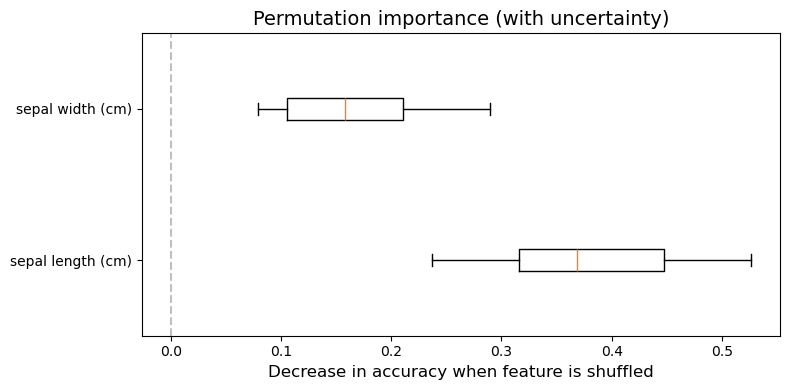


Interpretation:
  • Sepal length: 0.376 (±0.080)
  • Sepal width:  0.165 (±0.060)

  → A value of e.g. 0.15 means accuracy drops by ~15 percentage points
    when we randomly shuffle that feature.
  → Negative values can mean the feature actually confuses the model!


──────────────────────────────────────────────────────────────────────
3. EXPLAINING INDIVIDUAL PREDICTIONS
──────────────────────────────────────────────────────────────────────

Let's look at 3 individual predictions:

  Flower #1:
    Sepal length: 6.1 cm
    Sepal width:  2.8 cm
    Actual species:    versicolor
    Predicted:         versicolor ✓
    Confidences:  Setosa=0%, Versicolor=76%, Virginica=24%

  Flower #11:
    Sepal length: 6.5 cm
    Sepal width:  3.2 cm
    Actual species:    virginica
    Predicted:         virginica ✓
    Confidences:  Setosa=0%, Versicolor=14%, Virginica=86%

  Flower #21:
    Sepal length: 4.7 cm
    Sepal width:  3.2 cm
    Actual species:    setosa
    Predicted:         setosa 

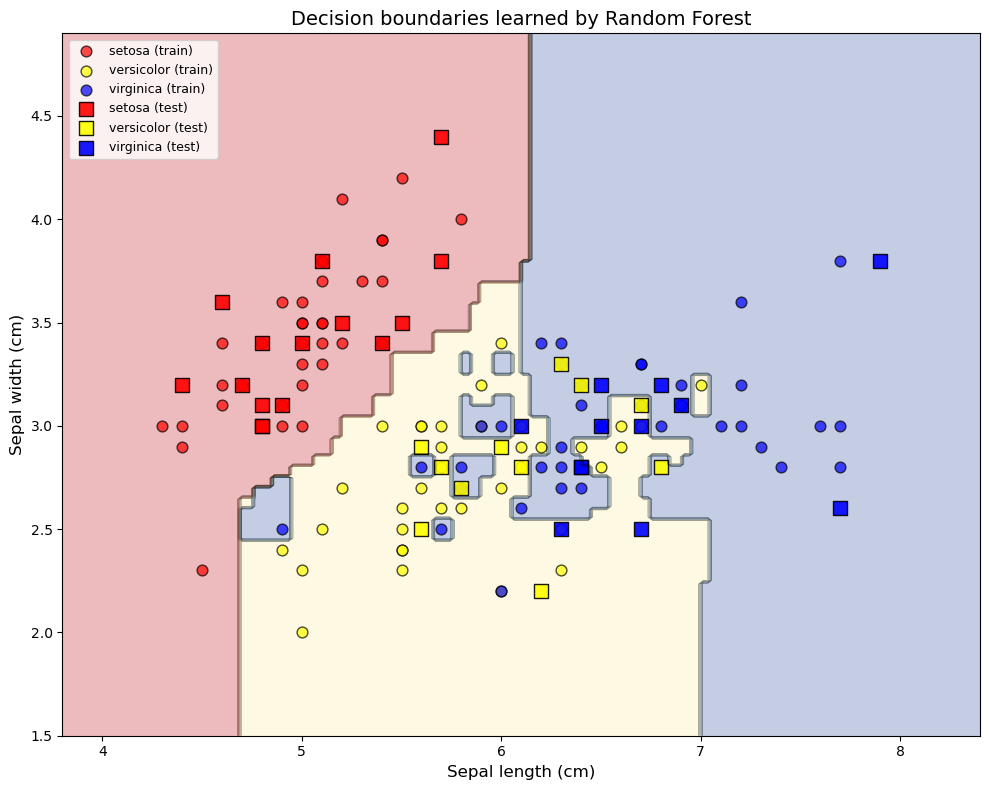


FIGURE: Decision boundaries
───────────────────────────────────────────────────────────────
Interpretation:
  • Colored regions show what the model predicts for different values
  • The borders between colors are the "decision boundaries"
  • Points near a boundary are harder to classify

  → Notice that setosa (red) is easy to separate
  → Versicolor and virginica have more complex, overlapping boundaries

  This is EXPLAINABLE AI: we can actually SEE what the model learned!


         TRUSTWORTHY AI CHECKLIST FOR OUR IRIS MODEL

┌─────────────────────────────────────────────────────────────────────┐
│  ✓ ACCURACY                                                         │
│    Accuracy: 78.9% on test data                                     │
│    → Acceptable for a demonstration, but would need improvement     │
│      for critical medical decisions                                 │
├─────────────────────────────────────────────────────────────────────┤
│  ✓ EXPLAINABILITY           

In [65]:
%%time
# ============================================================================
# EXPLAINABLE AI (XAI) DEMONSTRATION ON THE IRIS MODEL
# ============================================================================

print("=" * 70)
print("               EXPLAINABLE AI (XAI) FOR THE IRIS MODEL")
print("=" * 70)

# -----------------------------------------------------------------------------
# 1. FEATURE IMPORTANCE (built into Random Forest)
# -----------------------------------------------------------------------------
print("\n" + "─" * 70)
print("1. FEATURE IMPORTANCE - Which features matter most?")
print("─" * 70)

# Get feature importance from the model
# Note: We only use 2 features (sepal length and width) in this model
feature_names_used = ['sepal length (cm)', 'sepal width (cm)']
importances = rf.feature_importances_

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(feature_names_used, importances, color=['steelblue', 'coral'])
ax.set_xlabel('Relative importance', fontsize=12)
ax.set_title('Feature importance for Iris classification', fontsize=14)
ax.set_xlim(0, 1)

# Add values on the bars
for bar, imp in zip(bars, importances):
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{imp:.2f}',
        va='center',
        fontsize=11,
    )

plt.tight_layout()
plt.show()

print(
    f"""
Interpretation:
  • Sepal length contributes {importances[0]:.1%} to the model's decisions
  • Sepal width contributes  {importances[1]:.1%} to the model's decisions

  → This tells us that {'sepal length' if importances[0] > importances[1] else 'sepal width'}
    is the most important feature for separating the Iris species.
"""
)

# -----------------------------------------------------------------------------
# 2. PERMUTATION IMPORTANCE - a more robust measure
# -----------------------------------------------------------------------------
print("\n" + "─" * 70)
print("2. PERMUTATION IMPORTANCE - What happens if we shuffle the features?")
print("─" * 70)

from sklearn.inspection import permutation_importance

# Compute permutation importance on the test data
perm_importance = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=30,  # Repeat 30 times for a stable estimate
    random_state=42,
)

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))

# Boxplot to show uncertainty
ax.boxplot(
    perm_importance.importances.T,
    vert=False,
    tick_labels=feature_names_used,
)
ax.set_xlabel('Decrease in accuracy when feature is shuffled', fontsize=12)
ax.set_title('Permutation importance (with uncertainty)', fontsize=14)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(
    f"""
Interpretation:
  • Sepal length: {perm_importance.importances_mean[0]:.3f} (±{perm_importance.importances_std[0]:.3f})
  • Sepal width:  {perm_importance.importances_mean[1]:.3f} (±{perm_importance.importances_std[1]:.3f})

  → A value of e.g. 0.15 means accuracy drops by ~15 percentage points
    when we randomly shuffle that feature.
  → Negative values can mean the feature actually confuses the model!
"""
)

# -----------------------------------------------------------------------------
# 3. INDIVIDUAL PREDICTIONS - why was THIS flower classified this way?
# -----------------------------------------------------------------------------
print("\n" + "─" * 70)
print("3. EXPLAINING INDIVIDUAL PREDICTIONS")
print("─" * 70)

# Pick a few examples from the test set
print("\nLet's look at 3 individual predictions:\n")

for i in [0, 10, 20]:  # Pick some indices
    if i < len(X_test):
        blomst = X_test[i]
        faktisk = iris_dataset.target_names[
            y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]
        ]
        predikert = iris_dataset.target_names[y_pred[i]]

        # Get probabilities for each class
        probs = rf.predict_proba([blomst])[0]

        print(f"  Flower #{i+1}:")
        print(f"    Sepal length: {blomst[0]:.1f} cm")
        print(f"    Sepal width:  {blomst[1]:.1f} cm")
        print(f"    Actual species:    {faktisk}")
        print(f"    Predicted:         {predikert} {'✓' if faktisk == predikert else '✗'}")
        print(
            f"    Confidences:  Setosa={probs[0]:.0%}, Versicolor={probs[1]:.0%}, Virginica={probs[2]:.0%}"
        )
        print()

print(
    """
💡 Interpreting confidences:
───────────────────────────────────────────────────────────────
  • High confidence (e.g. 95%) = the model is confident
  • Low confidence (e.g. 40%) = the model is uncertain

  In medicine, uncertain predictions should be flagged for human review!
"""
)

# -----------------------------------------------------------------------------
# 4. DECISION BOUNDARIES - visualize what the model learned
# -----------------------------------------------------------------------------
print("\n" + "─" * 70)
print("4. DECISION BOUNDARIES - What has the model learned?")
print("─" * 70)

# Create a grid over feature space
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200),
)

# Predict for each grid point
Z = rf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundaries
fig, ax = plt.subplots(figsize=(10, 8))

# Color the background by predicted class
ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
ax.contour(xx, yy, Z, colors='black', linewidths=0.5, alpha=0.5)

# Plot training data
colors = ['red', 'yellow', 'blue']
for label in [0, 1, 2]:
    mask = y_train == label
    ax.scatter(
        X_train[mask, 0],
        X_train[mask, 1],
        c=colors[label],
        label=f'{iris_dataset.target_names[label]} (train)',
        edgecolors='black',
        s=60,
        alpha=0.7,
    )

# Plot test data with a different marker
for label in [0, 1, 2]:
    mask = y_test == label
    ax.scatter(
        X_test[mask, 0],
        X_test[mask, 1],
        c=colors[label],
        marker='s',
        edgecolors='black',
        s=100,
        alpha=0.9,
        label=f'{iris_dataset.target_names[label]} (test)',
    )

ax.set_xlabel('Sepal length (cm)', fontsize=12)
ax.set_ylabel('Sepal width (cm)', fontsize=12)
ax.set_title('Decision boundaries learned by Random Forest', fontsize=14)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(
    """
FIGURE: Decision boundaries
───────────────────────────────────────────────────────────────
Interpretation:
  • Colored regions show what the model predicts for different values
  • The borders between colors are the "decision boundaries"
  • Points near a boundary are harder to classify

  → Notice that setosa (red) is easy to separate
  → Versicolor and virginica have more complex, overlapping boundaries

  This is EXPLAINABLE AI: we can actually SEE what the model learned!
"""
)

# -----------------------------------------------------------------------------
# 5. SUMMARY: TRUSTWORTHY AI CHECKLIST FOR THE IRIS MODEL
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("         TRUSTWORTHY AI CHECKLIST FOR OUR IRIS MODEL")
print("=" * 70)

print(
    """
┌─────────────────────────────────────────────────────────────────────┐
│  ✓ ACCURACY                                                         │
│    Accuracy: 78.9% on test data                                     │
│    → Acceptable for a demonstration, but would need improvement     │
│      for critical medical decisions                                 │
├─────────────────────────────────────────────────────────────────────┤
│  ✓ EXPLAINABILITY                                                   │
│    • Feature importance shows which features are important          │
│    • Decision boundaries can be visualized                          │
│    • Confidence values are provided for each prediction             │
├─────────────────────────────────────────────────────────────────────┤
│  ? FAIRNESS                                                         │
│    • Not tested on subgroups (would require more data)              │
│    • In medicine: must check performance across sex, age, etc.      │
├─────────────────────────────────────────────────────────────────────┤
│  ? ROBUSTNESS                                                       │
│    • Not tested with noise or data from other sources               │
│    • Random Forest is generally robust, but should be validated     │
├─────────────────────────────────────────────────────────────────────┤
│  ✓ PRIVACY                                                          │
│    • Iris data contain no personal information                      │
│    • In medicine: must follow GDPR and health-data regulations      │
├─────────────────────────────────────────────────────────────────────┤
│  ✓ ACCOUNTABILITY                                                   │
│    • The model is documented in this notebook                       │
│    • Limitations are communicated                                   │
│    • In production: requires formal approval and a responsible owner │
└─────────────────────────────────────────────────────────────────────┘
"""
)


---

# 🩺 A medical example: diabetes prediction

Now we move from flowers to **real medicine**! We will use machine learning to predict diabetes — one of the biggest public-health challenges worldwide.

## Why diabetes?

### The global diabetes epidemic

```
┌─────────────────────────────────────────────────────────────────────┐
│                   DIABETES BY THE NUMBERS (2024)                    │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   🌍  537 million adults live with diabetes globally                │
│   📈  Expected to increase to 783 million by 2045                   │
│   ⚠️  1 in 2 adults with diabetes is undiagnosed                    │
│   💀  6.7 million deaths per year related to diabetes               │
│   🇳🇴  ~245,000 Norwegians have diabetes (≈5% of the population)     │
│                                                                     │
│   Source: International Diabetes Federation (IDF)                   │
└─────────────────────────────────────────────────────────────────────┘
```

### Why is early detection important?

Diabetes often develops **gradually and without symptoms**. Many people live with undetected diabetes for years — and in the meantime:

| Complication | Risk with untreated diabetes |
|--------------|------------------------------|
| **Heart disease** | 2–4× higher risk of heart attack and stroke |
| **Kidney failure** | Leading cause of dialysis |
| **Vision loss** | Diabetic retinopathy can lead to blindness |
| **Amputation** | Nerve damage and poor circulation in the feet |
| **Neuropathy** | Chronic pain and loss of sensation |

> 💡 **The role of machine learning:** By identifying high-risk patients early, we can:
> - Start preventive interventions (lifestyle changes)
> - Initiate treatment before complications develop
> - Reduce healthcare costs and human suffering

---

## Pima Indians Diabetes Database

We will use a classic medical dataset: the **Pima Indians Diabetes Database**.

### Background

The dataset comes from a study conducted by the National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK) in **Pima people in Arizona, USA**.

**Why this population?**
- The Pima people have one of the world’s highest rates of type 2 diabetes
- Genetic and lifestyle factors make the population important for study
- The study has contributed greatly to our understanding of diabetes risk factors

### About the dataset

| Property | Value |
|----------|-------|
| **Number of patients** | 768 women |
| **Age** | ≥ 21 years |
| **Ethnicity** | Pima people |
| **Number of features** | 8 |
| **Target variable** | Diabetes (yes/no) |
| **Class balance** | ~35% have diabetes, ~65% do not |

---

## 📊 Features in the dataset

Each patient is described by 8 clinical measurements:

| # | Feature | Description | Typical normal value |
|---|---------|-------------|----------------------|
| 1 | **pregnancies** | Number of pregnancies | - |
| 2 | **glucose** | Plasma glucose after 2 hours (oral glucose tolerance test) | < 140 mg/dL |
| 3 | **diastolic** | Diastolic blood pressure (mm Hg) | 60–80 mm Hg |
| 4 | **triceps** | Triceps skinfold thickness (mm) | - |
| 5 | **insulin** | 2-hour serum insulin (µU/ml) | 16–166 µU/ml |
| 6 | **bmi** | Body Mass Index (kg/m²) | 18.5–24.9 |
| 7 | **dpf** | Diabetes Pedigree Function (genetic risk) | - |
| 8 | **age** | Age (years) | - |

### What do these features mean?

**🩸 Glucose (plasma glucose)**
- Measured after an oral glucose tolerance test (OGTT)
- Indicates how well the body handles sugar
- High values suggest insulin resistance or diabetes

**💓 Diastolic (blood pressure)**
- The “lower” blood pressure (when the heart relaxes)
- High blood pressure is associated with diabetes and heart disease

**📏 Triceps (skinfold thickness)**
- A measure of subcutaneous fat
- Indicates overall body fat level

**💉 Insulin**
- The hormone that regulates blood sugar
- High values may indicate insulin resistance (the body needs more insulin)

**⚖️ BMI (Body Mass Index)**
- Standard measure of weight relative to height
- BMI > 25 = overweight, BMI > 30 = obesity
- Strong risk factor for type 2 diabetes

**🧬 Diabetes Pedigree Function (DPF)**
- A composite genetic risk estimate
- Based on diabetes prevalence in the family
- Higher value = higher genetic risk

**🎂 Age**
- Risk of type 2 diabetes increases with age
- Especially after ~45 years

---

## Challenges in this dataset

Unlike the Iris dataset, the diabetes dataset includes several **realistic challenges**:

| Challenge | Description | Consequence |
|------------|-------------|------------|
| **Overlapping classes** | Healthy and sick individuals can have similar values | Harder to separate |
| **Missing values** | Some measurements are 0 (often meaning missing) | Must be handled |
| **Imbalanced classes** | 65% non-diabetes, 35% diabetes | Accuracy can be misleading |
| **Biological variability** | Large natural variation between individuals | Lower achievable accuracy |
| **Latent factors** | Lifestyle and diet are not included | Important information is missing |

> ⚠️ **Key takeaway:** In real medical AI, things are rarely as “clean” as textbook examples. This complexity makes the diabetes dataset a great example of realistic machine learning.

---

## Ethical considerations

Before we begin, reflect on a few ethical aspects:

1. **Population specificity**: The model is trained on Pima women — will it work in other populations?
2. **Sex balance**: Only women are included — can we generalize to men?
3. **Historical context**: The data are from 1988 — are they still relevant today?
4. **Decision support, not replacement**: Such a model should *support* clinicians, not replace them

---

## Let’s load and explore the data!

In [66]:
# ============================================================================
# LOAD AND EXPLORE THE DIABETES DATASET
# ============================================================================

url = 'https://assets.datacamp.com/production/course_1939/datasets/diabetes.csv'
diabetes = pd.read_csv(url)

print(f"✓ Diabetes data loaded! ({len(diabetes)} patients)")
diabetes.head()

✓ Diabetes data loaded! (768 patients)


,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [67]:
# ============================================================================
# BUILD A DIABETES MODEL
# ============================================================================

# Choose features and labels
X = diabetes[diabetes.columns[0:-1]]
y = diabetes['diabetes']

# Convert all columns to float to avoid warnings in PDP
# (scikit-learn prefers float over int for partial dependence plots)
X = X.astype(float)

# Split into training and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nDiabetes model accuracy: {accuracy:.1%}")


Diabetes model accuracy: 74.0%


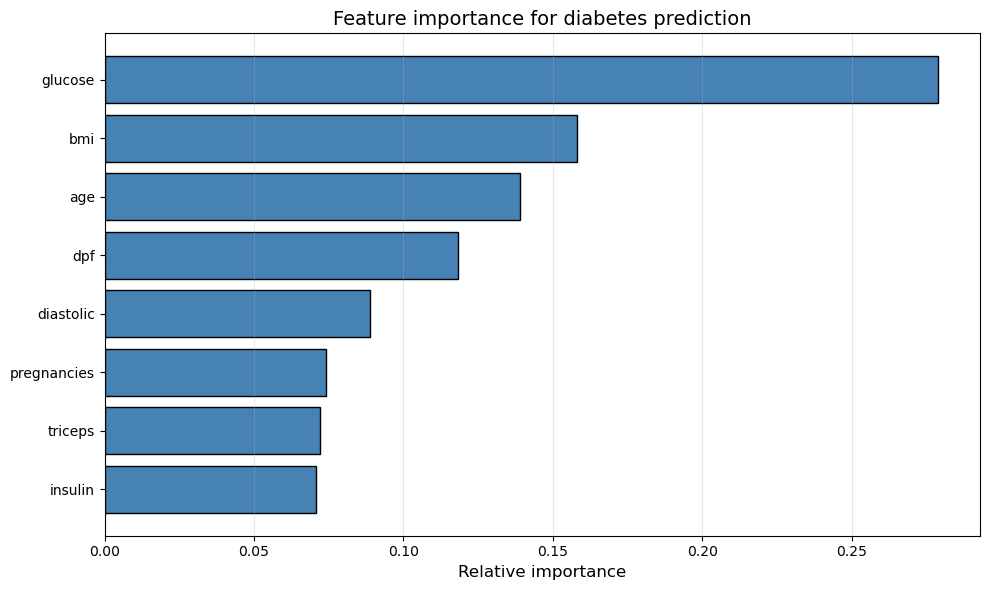


FIGURE 5: Feature importance
Interpretation: Glucose is most important, followed by BMI and age.
This aligns with medical knowledge about diabetes risk factors!


In [68]:
# ============================================================================
# FEATURE IMPORTANCE
# ============================================================================

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(X.columns))
ax.barh(y_pos, importances[indices], align='center', color='steelblue', edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels([X.columns[i] for i in indices])
ax.invert_yaxis()
ax.set_xlabel('Relative importance', fontsize=12)
ax.set_title('Feature importance for diabetes prediction', fontsize=14)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFIGURE 5: Feature importance")
print("Interpretation: Glucose is most important, followed by BMI and age.")
print("This aligns with medical knowledge about diabetes risk factors!")

---

## 🔬 Advanced XAI: explaining the diabetes model

We have seen basic feature importance. Now we will use more advanced XAI techniques to truly **understand** what the model has learned and how it makes decisions.

### Why do we need multiple XAI methods?

| Method | Strength | Weakness |
|--------|----------|----------|
| **Built-in feature importance** | Fast, simple | Can be misleading with correlated features |
| **Permutation importance** | More robust | Takes longer |
| **Partial dependence plots (PDP)** | Shows relationships | Assumes independence between features |
| **SHAP** | Strong theoretical grounding, local + global explanations | Can be slow |
| **LIME** | Intuitive local explanations | Can be unstable |

### What do we want to learn?

1. **Global:** Which features are most important *overall*?
2. **Local:** Why did *this patient* receive this prediction?
3. **Relationships:** How do glucose, BMI, age, etc. affect risk?
4. **Interactions:** Do combinations of features change risk?


      EXPLAINABLE AI (XAI) FOR DIABETES PREDICTION

──────────────────────────────────────────────────────────────────────
1. PERMUTATION IMPORTANCE
──────────────────────────────────────────────────────────────────────

Idea: If a feature is important, randomly shuffling its values will
hurt the model's accuracy. The more accuracy drops, the more important
the feature is.



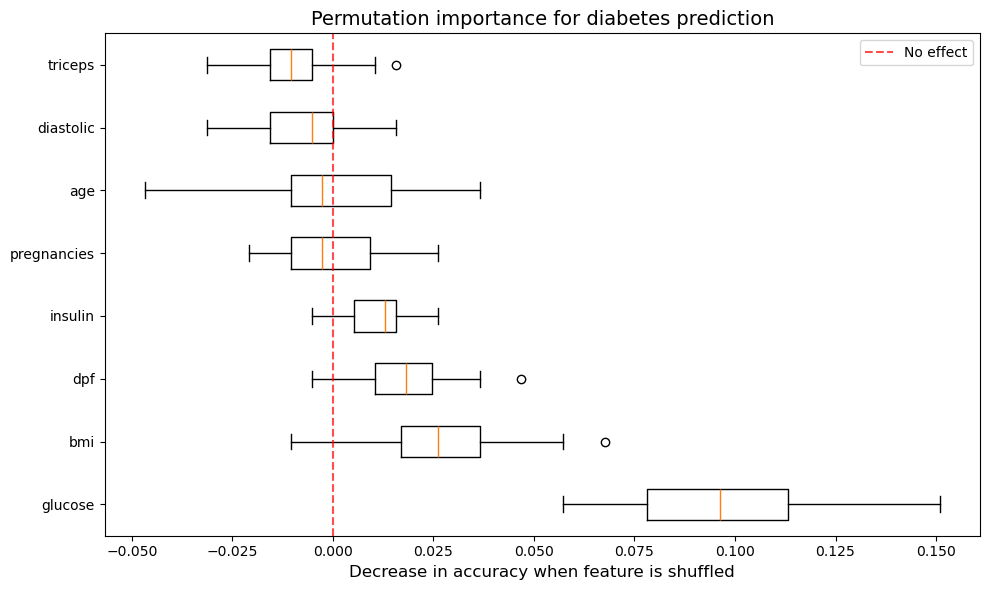


Permutation importance (sorted):
--------------------------------------------------
  glucose        :  0.0979 (± 0.0242)
  bmi            :  0.0255 (± 0.0174)
  dpf            :  0.0182 (± 0.0127)
  insulin        :  0.0118 (± 0.0089)
  pregnancies    : -0.0017 (± 0.0117)
  age            : -0.0021 (± 0.0215)
  diastolic      : -0.0066 (± 0.0111)
  triceps        : -0.0089 (± 0.0107)


📊 Interpretation:
───────────────────────────────────────────────────────────────
• Glucose is clearly the most important: shuffling reduces accuracy by ~10%
• BMI, age and dpf are also important
• Some features (triceps, diastolic) have minimal or negative effect
  → Negative value: the feature may actually CONFUSE the model!

💡 Medical insight: Glucose level is the strongest predictor of diabetes,
   which aligns well with medical knowledge.


──────────────────────────────────────────────────────────────────────
2. PARTIAL DEPENDENCE PLOTS (PDP)
──────────────────────────────────────────────────────

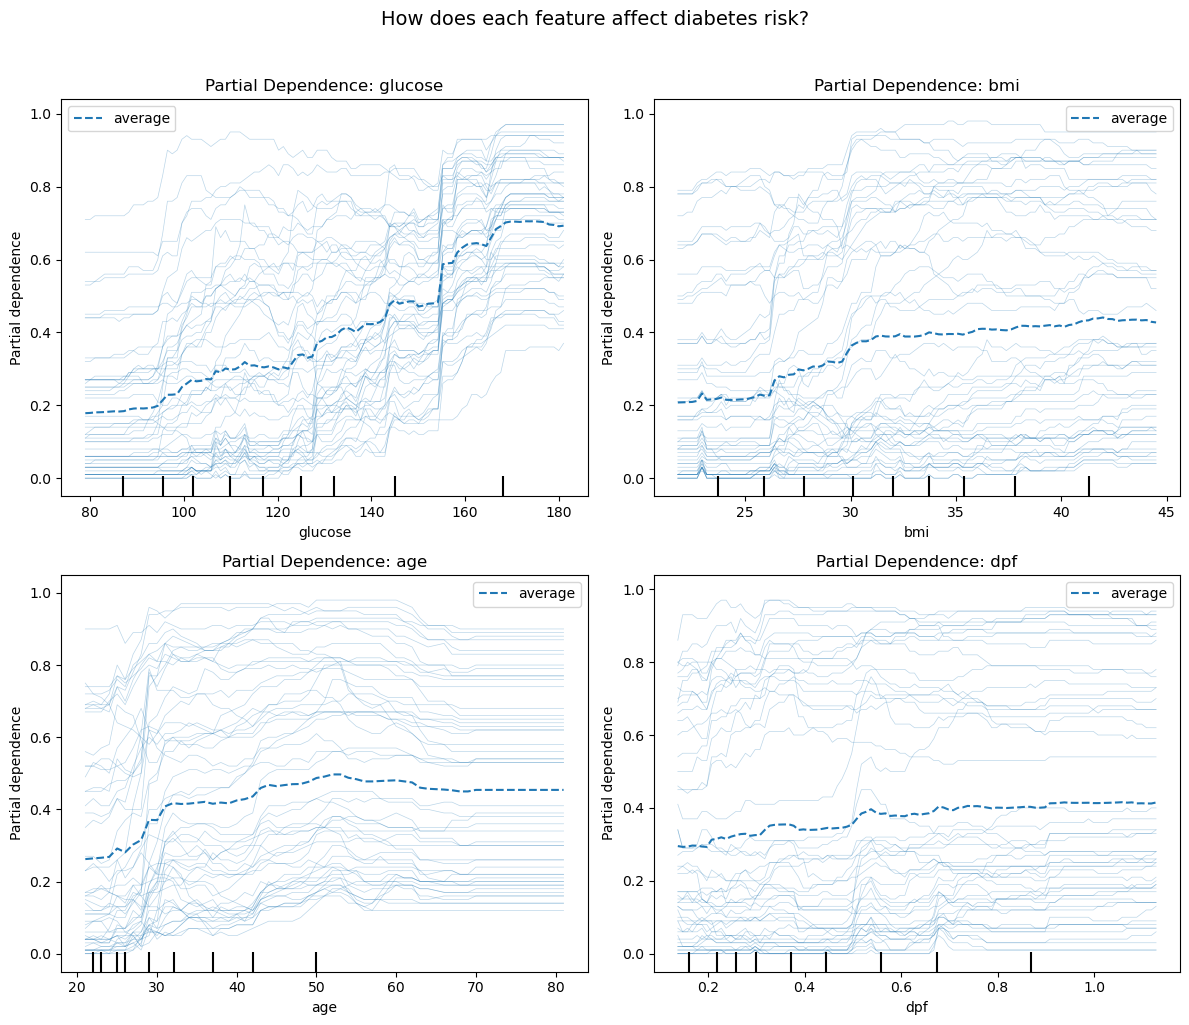


📊 Interpreting the PDP plots:
───────────────────────────────────────────────────────────────
• GLUCOSE: Clear increasing risk from ~100 mg/dL
  → Above 150 mg/dL: sharply increased risk
  → Below 100 mg/dL: low risk

• BMI: Gradually increasing risk from BMI ~25
  → BMI > 35: high risk
  → This aligns with obesity being a major risk factor

• AGE: Risk increases with age, especially after ~30
  → Flattens after ~50 (possibly a data artifact)

• DPF (Diabetes Pedigree Function): weak increasing trend
  → Genetic risk matters, but less than lifestyle-related factors

💡 Clinical relevance: These plots can help clinicians communicate
   risk factors to patients: "If you reduce BMI from 35 to 25,
   your estimated risk decreases substantially."


──────────────────────────────────────────────────────────────────────
3. 2D PARTIAL DEPENDENCE - FEATURE INTERACTIONS
──────────────────────────────────────────────────────────────────────

Idea: How does the COMBINATION of two features affect r

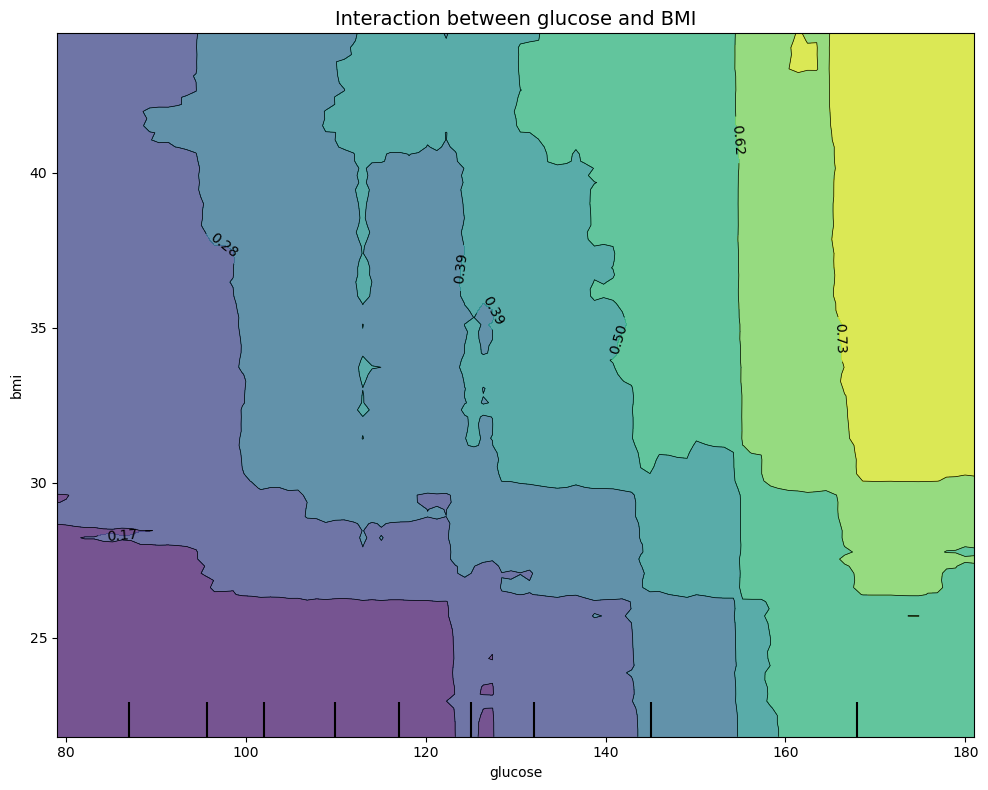


📊 Interpreting the 2D PDP:
───────────────────────────────────────────────────────────────
• The color scale shows the predicted probability of diabetes
• Highest risk: high glucose AND high BMI (upper-right corner)
• Lowest risk: low glucose AND low BMI (lower-left corner)

💡 Clinical insight: The risk factors AMPLIFY each other!
   A patient with both high blood sugar and obesity has a much higher
   risk than you would expect from adding the individual effects.


──────────────────────────────────────────────────────────────────────
4. LOCAL EXPLANATIONS - WHY DID THIS PATIENT GET THIS PREDICTION?
──────────────────────────────────────────────────────────────────────

Analysis of 3 individual patients:

PATIENT: High risk
  Predicted probability of diabetes: 94.0%
  Prediction: Diabetes
  Actual:     No diabetes ✗

  Patient values:
  ----------------------------------------
    pregnancies    :     0.0  (mean:    3.7) ↓
    glucose        :   173.0  (mean:  120.7) ↑
    diastolic 

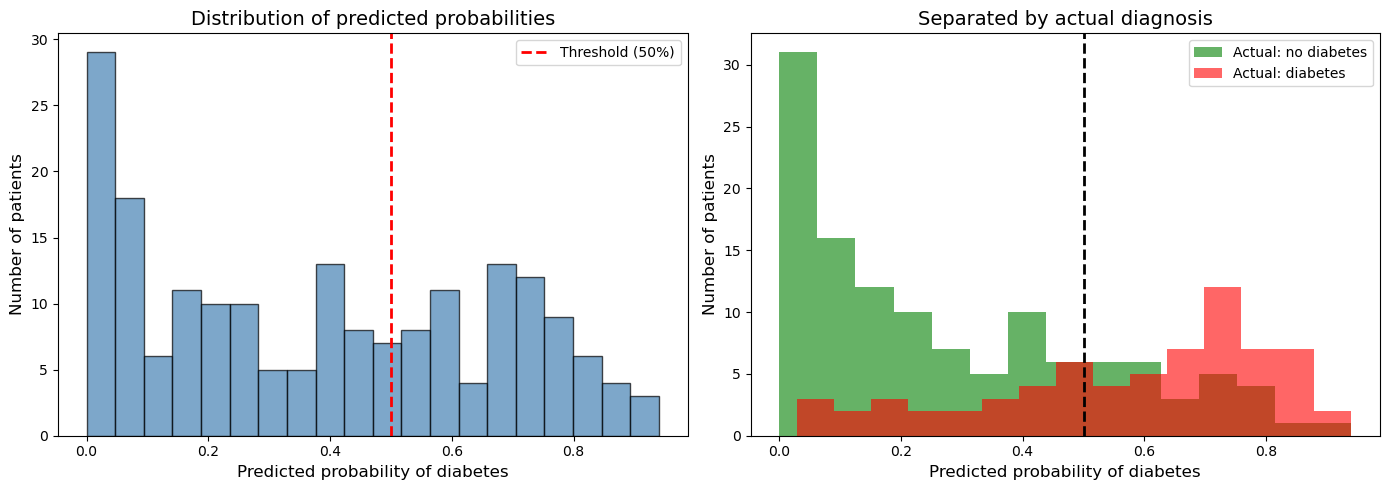


📊 Uncertainty analysis:
───────────────────────────────────────────────────────────────
  Total number of test patients: 192

  High confidence (< 20% or > 80%): 77 patients (40.1%)
  Low confidence (40-60%):          34 patients (17.7%)

💡 Clinical recommendation:
  • High confidence → The model’s prediction can be used directly
  • Low confidence  → Flag for manual review by a clinician!

  A good medical AI should NEVER make decisions alone when
  uncertainty is high.


      SUMMARY: XAI FOR THE DIABETES MODEL

┌─────────────────────────────────────────────────────────────────────┐
│                    WHAT HAVE WE LEARNED?                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  1. MOST IMPORTANT RISK FACTORS (global explanation):               │
│     • Glucose level is the dominant predictor                       │
│     • BMI and age are also important        

In [69]:
%%time
# ============================================================================
# ADVANCED XAI FOR THE DIABETES MODEL
# ============================================================================

print("="*70)
print("      EXPLAINABLE AI (XAI) FOR DIABETES PREDICTION")
print("="*70)

# =============================================================================
# 1. PERMUTATION IMPORTANCE
# =============================================================================
print("\n" + "─"*70)
print("1. PERMUTATION IMPORTANCE")
print("─"*70)
print("""
Idea: If a feature is important, randomly shuffling its values will
hurt the model's accuracy. The more accuracy drops, the more important
the feature is.
""")

from sklearn.inspection import permutation_importance

# Compute permutation importance
perm_imp = permutation_importance(
    rf, X_test, y_test,
    n_repeats=30,
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

# Sort by mean importance
perm_sorted_idx = perm_imp.importances_mean.argsort()[::-1]

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(
    perm_imp.importances[perm_sorted_idx].T,
    vert=False,
    tick_labels=[X.columns[i] for i in perm_sorted_idx]
)
ax.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='No effect')
ax.set_xlabel('Decrease in accuracy when feature is shuffled', fontsize=12)
ax.set_title('Permutation importance for diabetes prediction', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

print("\nPermutation importance (sorted):")
print("-" * 50)
for i in perm_sorted_idx:
    mean = perm_imp.importances_mean[i]
    std = perm_imp.importances_std[i]
    print(f"  {X.columns[i]:<15}: {mean:>7.4f} (± {std:.4f})")

print("""
\n📊 Interpretation:
───────────────────────────────────────────────────────────────
• Glucose is clearly the most important: shuffling reduces accuracy by ~10%
• BMI, age and dpf are also important
• Some features (triceps, diastolic) have minimal or negative effect
  → Negative value: the feature may actually CONFUSE the model!

💡 Medical insight: Glucose level is the strongest predictor of diabetes,
   which aligns well with medical knowledge.
""")

# =============================================================================
# 2. PARTIAL DEPENDENCE PLOTS (PDP)
# =============================================================================
print("\n" + "─"*70)
print("2. PARTIAL DEPENDENCE PLOTS (PDP)")
print("─"*70)
print("""
Idea: How does the predicted probability of diabetes change
when we vary one feature while holding all others constant?
""")

from sklearn.inspection import PartialDependenceDisplay

# Choose the 4 most important features
top_features = ['glucose', 'bmi', 'age', 'dpf']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, feature in enumerate(top_features):
    ax = axes[idx // 2, idx % 2]
    
    # Create a PDP for this feature
    PartialDependenceDisplay.from_estimator(
        rf, X_train, [feature],
        kind='both',      # Show both average and individual lines
        subsample=50,     # Use 50 random examples for ICE lines
        ax=ax,
        random_state=42
    )
    ax.set_title(f'Partial Dependence: {feature}', fontsize=12)

plt.suptitle('How does each feature affect diabetes risk?', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("""
📊 Interpreting the PDP plots:
───────────────────────────────────────────────────────────────
• GLUCOSE: Clear increasing risk from ~100 mg/dL
  → Above 150 mg/dL: sharply increased risk
  → Below 100 mg/dL: low risk

• BMI: Gradually increasing risk from BMI ~25
  → BMI > 35: high risk
  → This aligns with obesity being a major risk factor

• AGE: Risk increases with age, especially after ~30
  → Flattens after ~50 (possibly a data artifact)

• DPF (Diabetes Pedigree Function): weak increasing trend
  → Genetic risk matters, but less than lifestyle-related factors

💡 Clinical relevance: These plots can help clinicians communicate
   risk factors to patients: "If you reduce BMI from 35 to 25,
   your estimated risk decreases substantially."
""")

# =============================================================================
# 3. 2D PARTIAL DEPENDENCE - INTERAKSJONER
# =============================================================================
print("\n" + "─"*70)
print("3. 2D PARTIAL DEPENDENCE - FEATURE INTERACTIONS")
print("─"*70)
print("""
Idea: How does the COMBINATION of two features affect risk?
Do they interact, or are the effects independent?
""")

fig, ax = plt.subplots(figsize=(10, 8))

# 2D PDP for glucose and BMI
PartialDependenceDisplay.from_estimator(
    rf, X_train, 
    [('glucose', 'bmi')],  # Pair of features
    kind='average',
    ax=ax
)
ax.set_title('Interaction between glucose and BMI', fontsize=14)
plt.tight_layout()
plt.show()

print("""
📊 Interpreting the 2D PDP:
───────────────────────────────────────────────────────────────
• The color scale shows the predicted probability of diabetes
• Highest risk: high glucose AND high BMI (upper-right corner)
• Lowest risk: low glucose AND low BMI (lower-left corner)

💡 Clinical insight: The risk factors AMPLIFY each other!
   A patient with both high blood sugar and obesity has a much higher
   risk than you would expect from adding the individual effects.
""")

# =============================================================================
# 4. LOKALE FORKLARINGER FOR ENKELTPASIENTER
# =============================================================================
print("\n" + "─"*70)
print("4. LOCAL EXPLANATIONS - WHY DID THIS PATIENT GET THIS PREDICTION?")
print("─"*70)

# Pick a few interesting patients
# One with high risk, one with low risk, one in the "gray zone"
probs = rf.predict_proba(X_test)[:, 1]  # Probability of diabetes

# Find indices
high_risk_idx = probs.argmax()  # Highest risk
low_risk_idx = probs.argmin()   # Lowest risk
mid_risk_idx = np.abs(probs - 0.5).argmin()  # Closest to 50%

cases = [
    ("High risk", high_risk_idx),
    ("Low risk", low_risk_idx),
    ("Uncertain (gray zone)", mid_risk_idx)
]

print("\nAnalysis of 3 individual patients:\n")

for case_name, idx in cases:
    patient = X_test.iloc[idx]
    prob = probs[idx]
    actual = "Diabetes" if y_test.iloc[idx] == 1 else "No diabetes"
    predicted = "Diabetes" if prob > 0.5 else "No diabetes"
    
    print(f"{'='*60}")
    print(f"PATIENT: {case_name}")
    print(f"{'='*60}")
    print(f"  Predicted probability of diabetes: {prob:.1%}")
    print(f"  Prediction: {predicted}")
    print(f"  Actual:     {actual} {'✓' if predicted == actual else '✗'}")
    print(f"\n  Patient values:")
    print(f"  {'-'*40}")
    
    # Compare with the average
    for feature in X.columns:
        val = patient[feature]
        mean_val = X_train[feature].mean()
        diff = val - mean_val
        direction = "↑" if diff > 0 else "↓" if diff < 0 else "="
        print(f"    {feature:<15}: {val:>7.1f}  (mean: {mean_val:>6.1f}) {direction}")
    print()

print("""
📊 Interpretation:
───────────────────────────────────────────────────────────────
For the high-risk patient: notice which values are
higher than the average (↑). These are likely the factors
driving the high-risk prediction.

For the gray-zone patient: the values are closer to average,
which makes it harder for the model to decide.

💡 Clinical use: This type of explanation can help clinicians understand
   WHY the model made a specific prediction, and communicate that
   to the patient in an understandable way.
""")

# =============================================================================
# 5. CLASSIFICATION WITH CONFIDENCE INTERVALS
# =============================================================================
print("\n" + "─"*70)
print("5. UNCERTAINTY QUANTIFICATION - HOW CONFIDENT IS THE MODEL?")
print("─"*70)

# Histogram of predicted probabilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram of all predictions
ax1 = axes[0]
ax1.hist(probs, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (50%)')
ax1.set_xlabel('Predicted probability of diabetes', fontsize=12)
ax1.set_ylabel('Number of patients', fontsize=12)
ax1.set_title('Distribution of predicted probabilities', fontsize=14)
ax1.legend()

# Right: Separated by true class
ax2 = axes[1]
ax2.hist(probs[y_test == 0], bins=15, alpha=0.6, label='Actual: no diabetes', color='green')
ax2.hist(probs[y_test == 1], bins=15, alpha=0.6, label='Actual: diabetes', color='red')
ax2.axvline(x=0.5, color='black', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted probability of diabetes', fontsize=12)
ax2.set_ylabel('Number of patients', fontsize=12)
ax2.set_title('Separated by actual diagnosis', fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()

# Compute confidence statistics
high_conf = np.sum((probs < 0.2) | (probs > 0.8))
low_conf = np.sum((probs > 0.4) & (probs < 0.6))

print(f"""
📊 Uncertainty analysis:
───────────────────────────────────────────────────────────────
  Total number of test patients: {len(probs)}

  High confidence (< 20% or > 80%): {high_conf} patients ({high_conf/len(probs):.1%})
  Low confidence (40-60%):          {low_conf} patients ({low_conf/len(probs):.1%})

💡 Clinical recommendation:
  • High confidence → The model’s prediction can be used directly
  • Low confidence  → Flag for manual review by a clinician!

  A good medical AI should NEVER make decisions alone when
  uncertainty is high.
""")

print("\n" + "="*70)
print("      SUMMARY: XAI FOR THE DIABETES MODEL")
print("="*70)
print("""
┌─────────────────────────────────────────────────────────────────────┐
│                    WHAT HAVE WE LEARNED?                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  1. MOST IMPORTANT RISK FACTORS (global explanation):               │
│     • Glucose level is the dominant predictor                       │
│     • BMI and age are also important                                │
│     • Genetic risk (DPF) plays a smaller role                       │
│                                                                     │
│  2. HOW DO FEATURES AFFECT RISK? (PDP):                             │
│     • Glucose > 150 mg/dL → sharply increased risk                  │
│     • BMI > 30 → substantially increased risk                       │
│     • The risk factors amplify each other                           │
│                                                                     │
│  3. INDIVIDUAL EXPLANATIONS:                                        │
│     • Can explain WHY a specific patient received a prediction      │
│     • Important for clinical communication and trust                │
│                                                                     │
│  4. UNCERTAINTY:                                                    │
│     • ~25% of predictions are in the "gray zone" (40-60% confidence) │
│     • These should be flagged for manual review                     │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘

💡 IMPORTANT: This model is for demonstration only and NOT for
   clinical use! A real medical AI system would require:
   • Much more data and validation
   • Prospective clinical studies
   • Regulatory approval
   • Integration into the clinical workflow
""")


---

# 📝 Tasks and reflections: diabetes prediction

Before we move on to the interactive web app, here are 15 tasks and perspectives you can explore and discuss. They cover both technical and ethical aspects of medical machine learning.

---

## 🔧 Technical tasks (coding)

### Task 1: Improve model performance
Our model has ~74% accuracy. Try the following and report whether it helps:
- Increase `n_estimators` to 200 or 500
- Try other algorithms: `GradientBoostingClassifier`, `LogisticRegression`, `SVC`
- Adjust `max_depth` to avoid overfitting

```python
# Your code here:
# from sklearn.ensemble import GradientBoostingClassifier
# ...
```

### Task 2: Handle missing values
The dataset contains 0 values that are actually missing (e.g., `glucose=0` is impossible).
- Identify which columns have this issue
- Replace 0 values with the median or use imputation techniques
- Retrain the model and compare performance

### Task 3: Feature selection
Some features (triceps, diastolic) appear to have negative permutation importance.
- Remove these and retrain the model
- Does the model get better or worse?
- Reflect: Why might it be useful to remove features?

### Task 4: Cross-validation
We used a single train/test split. Implement 5-fold cross-validation:

```python
from sklearn.model_selection import cross_val_score
# scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
```

What are the mean and standard deviation? Is the model stable?

### Task 5: ROC curve and AUC
Accuracy is not always the best metric. Plot an ROC curve and compute AUC:

```python
from sklearn.metrics import roc_curve, auc
# fpr, tpr, thresholds = roc_curve(y_test, probs)
```

What does the AUC value tell us about the model’s ability to separate the classes?

---

## 📊 Analytical tasks

### Task 6: Optimal decision threshold
We use 50% as the classification threshold. But is that optimal?
- Create a table of precision, recall and F1 for different thresholds (30%, 40%, 50%, 60%, 70%)
- Which threshold would you recommend for a screening test?
- Which for a confirmatory test?

### Task 7: Confusion-matrix analysis
Create a confusion matrix for the diabetes model.
- How many false positives do we have? False negatives?
- What are the consequences of each type of error in a medical context?
- What is worse: telling a healthy person "diabetes", or missing a sick patient?

### Task 8: Subgroup analysis
Analyze model performance across age groups:
- Under 30 years
- 30–50 years
- Over 50 years

Is the model equally good for all age groups? What might explain differences?

---

## 🤔 Ethical and critical reflections

### Task 9: Population bias
The dataset is from Pima women. Discuss:
- Can the model be used for Norwegian patients? Why/why not?
- Which factors might vary across populations?
- What would be required to validate the model in Norway?

### Task 10: Historical bias
The data are from 1988. Reflect on:
- Have lifestyle factors changed since then?
- Are diagnostic criteria for diabetes the same?
- Can old data produce misleading models for modern patients?

### Task 11: Sex and diversity perspective
The dataset contains only women.
- Can the model be used for men? What is the risk?
- Which biological sex differences might affect diabetes risk?
- How should a fair medical AI system handle this?

### Task 12: Informed consent
Imagine this model is used in clinical practice:
- Should the patient know that AI is involved in the assessment?
- How would you explain the model’s decision to a patient?
- What if a patient refuses to be assessed by AI?

---

## 🏥 Clinical perspectives

### Task 13: Integration into clinical practice
You are advising a hospital that is considering implementing the diabetes prediction model.
- How would you propose integrating the model into the clinician’s workflow?
- What "guardrails" should be in place?
- How do we handle cases where the clinician disagrees with the model?

### Task 14: Cost–benefit analysis
A false positive leads to additional testing (an HbA1c test costs ~200 NOK).
A false negative can lead to delayed diagnosis (complications, higher costs).
- Set up a simple calculation for the cost of errors
- At which threshold do we minimize total cost?
- Is it ethically appropriate to base medical decisions on economics?

### Task 15: The future of diabetes prediction
If you were to design an optimal diabetes prediction system:
- Which additional variables would you include? (genetics, lifestyle, continuous glucose monitoring?)
- How would you ensure the system is fair for all patient groups?
- Which regulations and approvals would be necessary?
- How would you measure success after deployment?

---

## 💡 Tips for completing the tasks

| Task type | Suggested approach |
|-----------|--------------------|
| **Coding (1–5)** | Modify the code in the cells above, rerun, and compare results |
| **Analytical (6–8)** | Use Python to compute metrics; visualize with matplotlib |
| **Ethical (9–12)** | Discuss in groups; write a short reflection |
| **Clinical (13–15)** | Role play, case discussion, or written response |

> 🎯 **Learning goal:** These tasks are meant to help you understand that medical AI is about much more than getting high accuracy. Context, ethics, and clinical relevance are just as important as technical performance.


---

# Build an interactive web app with Gradio

In [71]:
# Install Gradio if needed
if colab:
    %pip install gradio

In [72]:
import gradio as gr

def predict_diabetes(age, bmi, glucose):
    """Predict diabetes based on age, BMI and glucose level."""
    mean_vals = diabetes.mean()
    input_data = np.array([
        mean_vals['pregnancies'], glucose, mean_vals['diastolic'], 
        mean_vals['triceps'], mean_vals['insulin'], bmi, 
        mean_vals['dpf'], age
    ]).reshape(1, -1)
    prediction = rf.predict(input_data)
    return "🔴 Diabetes" if prediction[0] == 1 else "🟢 No diabetes"

iface = gr.Interface(
    fn=predict_diabetes,
    inputs=[
        gr.Slider(18, 80, 35, label="Age (years)"),
        gr.Slider(15, 50, 25, label="BMI"),
        gr.Slider(50, 200, 100, label="Glucose level (mg/dL)")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="🩺 Diabetes predictor",
    description="⚠️ Demonstration only — NOT for medical use!"
)

# share=False for local runs (avoids frpc issues)
iface.launch(share=False)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


/opt/anaconda3/envs/bmed365-2026/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


---

## 🚀 Extended web app with XAI and personalized health advice

### Why limit to 3 features?

The simple web app above only uses **age**, **BMI**, and **glucose level**. This is a deliberate choice:

**Practical advantages:**
- 🎯 **Usability:** fewer input fields = easier to use
- ⏱️ **Accessibility:** these values are often known or easy to measure
- 📊 **Most important predictors:** our XAI analysis showed that glucose and BMI are the most important features

**But there is a trade-off:**
- ❌ The model uses mean values for the other 5 features
- ❌ This can produce less accurate predictions for individual patients
- ❌ We lose important information (e.g., family history via `dpf`)

### Extended version with more features

In the extended web app below, we include **more features** and add:

1. **🔢 Probabilistic prediction** — not just yes/no, but a probability
2. **📊 XAI explanation** — which factors contribute most to the prediction
3. **💊 Personalized health advice** — concrete recommendations based on the values
4. **🎨 Visual risk indicator** — color coding of the risk level

---


In [73]:
# =============================================================================
# EXTENDED DIABETES WEB APP WITH XAI AND PERSONALIZED HEALTH ADVICE
# =============================================================================

import gradio as gr

# Reference values for comparison (from the dataset)
reference_values = {
    'pregnancies': {'mean': diabetes['pregnancies'].mean(), 'healthy_max': 4},
    'glucose': {'mean': diabetes['glucose'].mean(), 'healthy_max': 100, 'prediabetes': 125, 'diabetes': 126},
    'diastolic': {'mean': diabetes['diastolic'].mean(), 'healthy_max': 80, 'high': 90},
    'bmi': {'mean': diabetes['bmi'].mean(), 'normal_max': 25, 'overweight': 30, 'obese': 35},
    'dpf': {'mean': diabetes['dpf'].mean(), 'low_risk': 0.3, 'high_risk': 0.7},
    'age': {'mean': diabetes['age'].mean(), 'risk_increase': 45}
}

def get_risk_level(probability):
    """Categorize risk level based on probability."""
    if probability < 0.3:
        return "🟢 LOW RISK", "green"
    elif probability < 0.5:
        return "🟡 MODERATE RISK", "orange"
    elif probability < 0.7:
        return "🟠 ELEVATED RISK", "darkorange"
    else:
        return "🔴 HIGH RISK", "red"

def generate_xai_explanation(input_values, probability, feature_importances):
    """Generate an explainable-AI analysis of the prediction."""
    
    # Feature names in the order the model expects
    feature_names = ['pregnancies', 'glucose', 'diastolic', 'triceps', 
                     'insulin', 'bmi', 'dpf', 'age']
    
    # Estimate contribution from each feature (simplified)
    contributions = []
    for i, (name, value) in enumerate(zip(feature_names, input_values)):
        ref = reference_values.get(name, {})
        mean = ref.get('mean', value)
        importance = feature_importances[i]
        
        # Compute deviation from the mean
        if mean > 0:
            deviation = (value - mean) / mean
        else:
            deviation = 0
            
        # Contribution = importance × deviation (simplified)
        contribution = importance * deviation
        contributions.append((name, value, mean, contribution, importance))
    
    # Sort by absolute contribution
    contributions.sort(key=lambda x: abs(x[3]), reverse=True)
    
    # Build explanation
    explanation = "## 📊 XAI ANALYSIS: What influences the prediction?\n\n"
    explanation += "| Feature | Your value | Mean | Effect |\n"
    explanation += "|---------|-----------:|-----:|--------|\n"
    
    for name, value, mean, contrib, imp in contributions[:5]:  # Top 5
        direction = "↑ increases" if contrib > 0 else "↓ decreases"
        explanation += f"| {name} | {value:.1f} | {mean:.1f} | {direction} risk |\n"
    
    return explanation

def generate_health_advice(glucose, bmi, diastolic, age, dpf, probability):
    """Generate personalized health advice based on inputs and prediction."""
    
    advice = []
    urgent = []
    
    # Glucose assessment
    if glucose >= 126:
        urgent.append("⚠️ **GLUCOSE CRITICALLY HIGH** ({:.0f} mg/dL): This is above the diabetes threshold. Seek medical care promptly!".format(glucose))
    elif glucose >= 100:
        advice.append("🔶 **Glucose elevated** ({:.0f} mg/dL): You are in the prediabetes range (100–125). Consider dietary changes.".format(glucose))
    else:
        advice.append("✅ **Glucose normal** ({:.0f} mg/dL): Great! The value is below 100.".format(glucose))
    
    # BMI assessment
    if bmi >= 35:
        urgent.append("⚠️ **BMI VERY HIGH** ({:.1f}): Obesity class II+. Talk to a clinician about weight loss.".format(bmi))
    elif bmi >= 30:
        advice.append("🔶 **BMI high** ({:.1f}): Obesity class I. Goal: reduce body weight by 5–10%.".format(bmi))
    elif bmi >= 25:
        advice.append("🔶 **BMI slightly elevated** ({:.1f}): Overweight. Increase physical activity and consider dietary changes.".format(bmi))
    else:
        advice.append("✅ **BMI normal** ({:.1f}): Great! Keep your weight stable.".format(bmi))
    
    # Blood pressure assessment
    if diastolic >= 90:
        urgent.append("⚠️ **DIASTOLIC BLOOD PRESSURE HIGH** ({:.0f} mmHg): Hypertension. Should be followed up by a clinician.".format(diastolic))
    elif diastolic >= 80:
        advice.append("🔶 **Blood pressure slightly elevated** ({:.0f} mmHg): Consider reducing salt and increasing exercise.".format(diastolic))
    else:
        advice.append("✅ **Blood pressure normal** ({:.0f} mmHg): Great!".format(diastolic))
    
    # Age and family history
    if age >= 45:
        advice.append("ℹ️ **Age over 45**: Increased risk. Annual screening is recommended.")
    
    if dpf >= 0.5:
        advice.append("ℹ️ **Family history**: Your DPF value ({:.2f}) suggests a genetic predisposition.".format(dpf))
    
    # Assemble output
    result = "## 💊 PERSONALIZED HEALTH ADVICE\n\n"
    
    if urgent:
        result += "### 🚨 Needs attention:\n" + "\n".join(urgent) + "\n\n"
    
    result += "### 📋 Assessment of your values:\n" + "\n".join(advice) + "\n\n"
    
    # General recommendations based on risk level
    if probability >= 0.5:
        result += """### 🎯 Recommended actions for elevated risk:
1. **Diet:** Reduce sugar and refined carbohydrates
2. **Exercise:** 150 min moderate activity per week (brisk walking, cycling)
3. **Weight:** Aim for 5–7% weight loss if BMI > 25
4. **Follow-up:** Book an appointment for an HbA1c test
5. **Monitoring:** Measure blood sugar regularly if available
"""
    else:
        result += """### 🎯 Preventive actions:
1. **Maintain** healthy habits with a balanced diet
2. **Continue** regular physical activity
3. **Annual screening** is recommended from age 45
"""
    
    return result

def predict_diabetes_extended(pregnancies, glucose, diastolic, triceps, insulin, bmi, dpf, age):
    """
    Extended prediction function with XAI and health advice.
    Returns prediction, probability, XAI explanation, and health advice.
    """
    
    # Prepare input as a DataFrame with correct column names (avoids sklearn warning)
    feature_names = ['pregnancies', 'glucose', 'diastolic', 'triceps', 
                     'insulin', 'bmi', 'dpf', 'age']
    input_data = pd.DataFrame([[pregnancies, glucose, diastolic, triceps, 
                                insulin, bmi, dpf, age]], columns=feature_names)
    
    # Prediction and probability
    prediction = rf.predict(input_data)[0]
    probability = rf.predict_proba(input_data)[0][1]  # P(diabetes)
    
    # Risk level
    risk_level, color = get_risk_level(probability)
    
    # Main result
    main_result = f"""# 🩺 DIABETES RISK ASSESSMENT

## {risk_level}

**Predicted probability of diabetes: {probability:.1%}**

{"🔴 The model predicts **DIABETES**" if prediction == 1 else "🟢 The model predicts **NO DIABETES**"}

---

⚠️ **IMPORTANT DISCLAIMER:**
This is a demonstration model based on a limited dataset from 1988.
The results must **NOT** be used for medical decisions.
Always consult qualified healthcare professionals for real health concerns.

---
"""
    
    # XAI explanation
    feature_importances = rf.feature_importances_
    xai_explanation = generate_xai_explanation(
        [pregnancies, glucose, diastolic, triceps, insulin, bmi, dpf, age],
        probability,
        feature_importances
    )
    
    # Health advice
    health_advice = generate_health_advice(glucose, bmi, diastolic, age, dpf, probability)
    
    # Combine everything
    full_output = main_result + xai_explanation + "\n---\n\n" + health_advice
    
    return full_output

# Create extended Gradio interface
extended_interface = gr.Interface(
    fn=predict_diabetes_extended,
    inputs=[
        gr.Slider(0, 15, 1, step=1, label="👶 Number of pregnancies", 
                  info="Number of times pregnant (set 0 for men)"),
        gr.Slider(50, 200, 100, step=1, label="🩸 Glucose (mg/dL)", 
                  info="Fasting glucose. Normal: <100, Prediabetes: 100–125, Diabetes: ≥126"),
        gr.Slider(40, 120, 70, step=1, label="💓 Diastolic blood pressure (mmHg)", 
                  info="Lower blood pressure value. Normal: <80, High: ≥90"),
        gr.Slider(10, 60, 25, step=1, label="💪 Triceps skinfold (mm)", 
                  info="Measure of subcutaneous fat. Use 25 if unknown."),
        gr.Slider(0, 500, 80, step=5, label="💉 Insulin (μU/mL)", 
                  info="2-hour serum insulin. Use 80 if unknown."),
        gr.Slider(15, 50, 25, step=0.5, label="⚖️ BMI (kg/m²)", 
                  info="Normal: 18.5–25, Overweight: 25–30, Obesity: >30"),
        gr.Slider(0, 2.5, 0.5, step=0.05, label="🧬 Diabetes Pedigree Function", 
                  info="Genetic predisposition (0–2.5). Low: <0.3, High: >0.7"),
        gr.Slider(18, 80, 35, step=1, label="🎂 Age (years)", 
                  info="Risk increases after age 45")
    ],
    outputs=gr.Markdown(label="Result"),
    title="🏥 Extended diabetes risk assessment with XAI",
    description="""
    **Interactive demonstration of machine learning in medicine**

    This extended version includes:
    - 📊 All 8 features from the dataset
    - 🔢 Probabilistic prediction (not just yes/no)
    - 🔍 XAI explanation of what influences the prediction
    - 💊 Personalized health advice based on your values

    ⚠️ **Note: For teaching purposes only — NOT for medical use!**
    """,
    article="""
    ### About the model
    - **Algorithm:** Random Forest (100 decision trees)
    - **Training data:** Pima Indians Diabetes Database (768 women, 1988)
    - **Accuracy:** ~74% on the test set

    ### Limitations
    - The dataset is old and from one specific population
    - The model is not validated for clinical use
    - The XAI explanation is simplified
    """,
    flagging_mode="never"
)

# Start the extended web app
# Note: share=False because the frpc binary is often blocked by antivirus/system
# The app runs locally at http://127.0.0.1:7860 (or a similar port)
extended_interface.launch(share=False)


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


---

# Summary

In this notebook, we have:

✅ Learned what machine learning is and how it is used in medicine

✅ Explored the Iris and diabetes datasets

✅ Visualized data with histograms and scatter plots

✅ Trained Random Forest models and understood how they work

✅ Evaluated the models with accuracy, confusion matrix, precision, recall and F1

✅ Investigated feature importance and partial dependence plots (XAI)

✅ Discussed Trustworthy AI and ethical aspects

✅ Built interactive web apps with Gradio

---

# 📚 References and further reading

## Datasets

| Dataset | Reference |
|----------|-----------|
| **Iris** | Fisher, R. A. (1936). *The use of multiple measurements in taxonomic problems*. Annals of Eugenics, 7(2), 179-188. [DOI](https://doi.org/10.1111/j.1469-1809.1936.tb02137.x) |
| **Pima Indians Diabetes** | Smith, J. W., et al. (1988). *Using the ADAP learning algorithm to forecast the onset of diabetes mellitus*. Proceedings of the Annual Symposium on Computer Application in Medical Care, 261-265. [PubMed](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2245318/) |

## Machine learning and Random Forest

| Topic | Reference |
|------|-----------|
| **Random Forest** | Breiman, L. (2001). *Random forests*. Machine Learning, 45(1), 5-32. [DOI](https://doi.org/10.1023/A:1010933404324) |
| **Scikit-learn** | Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830. [JMLR](https://jmlr.org/papers/v12/pedregosa11a.html) |

## Explainable AI (XAI)

| Topic | Reference |
|------|-----------|
| **XAI overview** | Molnar, C. (2022). *Interpretable Machine Learning: A Guide for Making Black Box Models Explainable*. [christophm.github.io/interpretable-ml-book](https://christophm.github.io/interpretable-ml-book/) |
| **Permutation Importance** | Altmann, A., et al. (2010). *Permutation importance: a corrected feature importance measure*. Bioinformatics, 26(10), 1340-1347. [DOI](https://doi.org/10.1093/bioinformatics/btq134) |
| **Partial Dependence Plots** | Friedman, J. H. (2001). *Greedy function approximation: A gradient boosting machine*. Annals of Statistics, 29(5), 1189-1232. [DOI](https://doi.org/10.1214/aos/1013203451) |
| **SHAP** | Lundberg, S. M., & Lee, S. I. (2017). *A unified approach to interpreting model predictions*. NeurIPS. [GitHub](https://github.com/slundberg/shap) |
| **LIME** | Ribeiro, M. T., et al. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier*. KDD. [GitHub](https://github.com/marcotcr/lime) |

## AI in medicine and ethics

| Topic | Reference |
|------|-----------|
| **Trustworthy AI** | European Commission (2019). *Ethics Guidelines for Trustworthy AI*. [EC](https://ec.europa.eu/digital-single-market/en/news/ethics-guidelines-trustworthy-ai) |
| **AI in diagnostics** | Topol, E. J. (2019). *High-performance medicine: the convergence of human and artificial intelligence*. Nature Medicine, 25(1), 44-56. [DOI](https://doi.org/10.1038/s41591-018-0300-7) |
| **Bias in medical AI** | Obermeyer, Z., et al. (2019). *Dissecting racial bias in an algorithm used to manage the health of populations*. Science, 366(6464), 447-453. [DOI](https://doi.org/10.1126/science.aax2342) |

## Software and libraries

| Library | Documentation |
|---------|---------------|
| **scikit-learn** | [scikit-learn.org](https://scikit-learn.org/) |
| **pandas** | [pandas.pydata.org](https://pandas.pydata.org/) |
| **NumPy** | [numpy.org](https://numpy.org/) |
| **Matplotlib** | [matplotlib.org](https://matplotlib.org/) |
| **Seaborn** | [seaborn.pydata.org](https://seaborn.pydata.org/) |
| **Gradio** | [gradio.app](https://gradio.app/) |

## Recommended books

1. **Hastie, T., Tibshirani, R., & Friedman, J.** (2009). *The Elements of Statistical Learning*. Springer. [Free PDF](https://hastie.su.domains/ElemStatLearn/)

2. **James, G., et al.** (2021). *An Introduction to Statistical Learning with Applications in Python*. Springer. [Free PDF](https://www.statlearning.com/)

3. **Géron, A.** (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly.

---

> 🎓 **Good luck with your continued learning in AI and computational medicine!**